# **PhonePe Digital Payments Analysis**

## **Project Overview**

This project analyzes PhonePe transaction and user data across Indian states and districts from 2018 Q1 to 2021 Q2.

The analysis explores transaction trends, popular transaction types, device-brand usage, app opens, district population density, and the relationship between demographic factors and transaction activity.

The goal is to understand how PhonePe usage changed over time and identify meaningful patterns across different regions.

## **Executive Summary**

### **Key Findings at a Glance**

- **Rapid growth:** Quarterly transactions rose from **134 million** in 2018 Q1 to **3.94 billion** in 2021 Q2, about **29 times** higher, with a temporary dip of 10.75% in 2020 Q2 during the national lockdown period.
- **A changing payment mix:** Merchant payments rose from **4.0%** to **38.0%** of transactions, while recharge and bill payments fell from **54.0%** to **17.4%**. Peer-to-peer payments remained the largest category in most quarters.
- **Concentrated volume:** Karnataka, Maharashtra and Telangana together account for about **39.7%** of all transactions, and the top ten states account for about **80.3%**.
- **Room for user growth:** Only **15 of 36** states are at or above the national users-to-population ratio of **24.7%**. Uttar Pradesh (**15.4%**) and Bihar (**14.4%**) are well below it despite their large populations.
- **Device concentration:** By 2021 Q2, the top five brands (Xiaomi, Samsung, Vivo, Oppo and Realme) accounted for **82.8%** of registered users, up from **73.1%** in 2018 Q1.
- **Deeper engagement:** The share of app opens that ended in a transaction rose from **31.8%** in 2019 Q3 to **40.9%** in 2021 Q2.

*Note: the data covers PhonePe only, and "users" means registered users (sign-ups), not necessarily active users.*

## **Datasets Used**

This project uses five datasets from the PhonePe Pulse data:

- **State_Txn and Users**: State-level transaction counts, transaction amount, registered users, and app opens.
- **State_TxnSplit**: Transaction details by type, such as peer-to-peer payments, merchant payments, and recharge or bill payments.
- **State_DeviceData**: Device brands used by registered PhonePe users in each state.
- **District_Txn and Users**: District-level transactions, registered users, and app opens.
- **District Demographics**: District population, area, population density, and district codes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_theme(style="whitegrid")
sns.set_theme(style="white")

In [2]:
PHONEPE_PURPLE = "#5F259F"
PHONEPE_LIGHT_PURPLE = "#A66FCC"
PHONEPE_DARK_PURPLE = "#3D1766"
MONEY_GREEN = "#2E7D32"

In [3]:
DATA_PATH = "phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"

In [4]:
txns = pd.read_excel(DATA_PATH, sheet_name="State_Txn and Users")
txns_split = pd.read_excel(DATA_PATH, sheet_name="State_TxnSplit")
sd = pd.read_excel(DATA_PATH, sheet_name="State_DeviceData")
district_txns = pd.read_excel(DATA_PATH, sheet_name="District_Txn and Users")
district_demo = pd.read_excel(DATA_PATH, sheet_name="District Demographics")

latest_year = txns["Year"].max()
latest_quarter = txns[txns["Year"] == latest_year]["Quarter"].max()

## **Data Understanding**

Before starting the analysis, the datasets are briefly reviewed to understand their columns, data types, and overall structure.

In [5]:
txns.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [6]:
txns_split.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [7]:
mid = len(sd) // 2

In [8]:
sd.iloc[mid - 5 : mid + 5]

,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


In [9]:
district_txns.head(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


In [10]:
district_txns.tail(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


In [11]:
district_demo.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
10,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


In [12]:
pd.set_option("display.float_format","{:,.2f}".format)

In [13]:
txns.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.00,504.00,504.00,503.00,504.00,504.00,504.00
mean,"2,019.29",2.36,"40,740,000.58","70,833,320,601.59","1,993.47","4,777,500.89","97,744,705.23"
std,1.03,1.11,"82,287,143.49","144,090,233,156.01",607.46,"6,644,495.72","204,237,579.80"
min,"2,018.00",1.00,778.00,"1,928,611.18",0.00,501.00,0.00
25%,"2,018.00",1.00,"592,557.75","1,167,157,028.93","1,598.91","157,420.25",0.00
50%,"2,019.00",2.00,"6,217,487.00","10,516,054,014.09","1,861.38","1,747,914.00","2,930,573.50"
75%,"2,020.00",3.00,"43,636,745.50","69,470,450,912.08","2,259.09","7,320,945.25","86,150,218.25"
max,"2,021.00",4.00,"573,616,486.00","1,027,958,332,797.58","3,938.73","39,664,697.00","1,208,083,592.00"


In [14]:
txns_split.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,"2,514.00","2,514.00","2,514.00","2,514.00","2,514.00"
mean,"2,019.29",2.36,"8,167,446.42","14,439,779,209.54","1,349.93"
std,1.03,1.11,"24,236,453.68","59,950,544,781.05","1,534.87"
min,"2,018.00",1.00,2.00,34.40,17.20
25%,"2,018.00",1.00,"27,880.75","17,624,121.73",385.74
50%,"2,019.00",2.00,"268,798.00","190,118,948.89",720.94
75%,"2,020.00",3.00,"3,683,230.25","2,661,247,757.00","1,352.79"
max,"2,021.00",4.00,"279,599,017.00","872,151,973,637.89","7,767.54"


In [15]:
sd.describe()

,Year,Quarter,Registered Users,Percentage
count,"5,544.00","5,544.00","5,544.00","5,544.00"
mean,"2,019.29",2.36,"434,318.26",0.09
std,1.03,1.11,"905,606.95",0.08
min,"2,018.00",1.00,10.00,0.01
25%,"2,018.00",1.00,"8,055.75",0.02
50%,"2,019.00",2.00,"74,422.50",0.06
75%,"2,020.00",3.00,"397,887.50",0.14
max,"2,021.00",4.00,"9,764,252.00",0.48


In [16]:
district_txns.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,"10,248.00","10,248.00","10,248.00","10,248.00","10,244.00","10,248.00","10,248.00"
mean,"2,019.29",2.36,"2,003,606.59","3,542,311,176.11","1,909.80","234,959.06","4,807,116.65"
std,1.03,1.11,"9,613,466.29","14,731,537,479.50",600.94,"460,597.83","15,625,414.80"
min,"2,018.00",1.00,0.00,0.00,84.94,22.00,0.00
25%,"2,018.00",1.00,"103,141.75","175,666,805.61","1,554.59","36,195.50",0.00
50%,"2,019.00",2.00,"376,306.50","678,456,240.46","1,863.14","106,764.00","640,302.50"
75%,"2,020.00",3.00,"1,272,815.00","2,377,255,936.80","2,203.08","257,316.50","4,346,319.50"
max,"2,021.00",4.00,"348,712,787.00","444,422,398,357.68","11,209.98","10,604,609.00","554,419,656.00"


In [17]:
district_demo.describe()

,Population,Area (sq km),Density
count,742.00,742.00,742.00
mean,"1,668,554.61","4,395.37",838.51
std,"1,458,849.18","4,254.68","2,754.41"
min,0.00,0.00,0.00
25%,"653,081.50","2,039.75",198.00
50%,"1,322,359.00","3,402.50",353.00
75%,"2,297,440.00","5,432.75",686.25
max,"10,082,852.00","45,652.00","36,155.00"


In [18]:
print("txns:")
print(txns.dtypes)

print("\ntxns_split:")
print(txns_split.dtypes)

print("\nsd:")
print(sd.dtypes)

print("\ndistrict_txns:")
print(district_txns.dtypes)

print("\ndistrict_demo:")
print(district_demo.dtypes)

txns:
State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

txns_split:
State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

sd:
State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

district_txns:
State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

district_demo:
State              o

## **Data Quality and Cleaning**

This section checks for missing values and resolves the one missing transaction amount found in the state-level dataset.

In [19]:
txns.isnull().sum()

,0
State,0
Year,0
Quarter,0
Transactions,0
Amount (INR),1
ATV (INR),0
Registered Users,0
App Opens,0


In [20]:
txns.isnull().sum() / len(txns) * 100

,0
State,0.00
Year,0.00
Quarter,0.00
Transactions,0.00
Amount (INR),0.20
ATV (INR),0.00
Registered Users,0.00
App Opens,0.00


In [21]:
(txns.isnull().sum() / len(txns) * 100).idxmax()

'Amount (INR)'

In [22]:
txns_split.isnull().sum()

,0
State,0
Year,0
Quarter,0
Transaction Type,0
Transactions,0
Amount (INR),0
ATV (INR),0


In [23]:
sd.isnull().sum()

,0
State,0
Year,0
Quarter,0
Brand,0
Registered Users,0
Percentage,0


In [24]:
district_txns.isnull().sum()

,0
State,0
Year,0
Quarter,0
District,0
Code,28
Transactions,0
Amount (INR),0
ATV (INR),4
Registered Users,0
App Opens,0


In [25]:
district_txns.isnull().sum()/len(district_txns)*100

,0
State,0.00
Year,0.00
Quarter,0.00
District,0.00
Code,0.27
Transactions,0.00
Amount (INR),0.00
ATV (INR),0.04
Registered Users,0.00
App Opens,0.00


In [26]:
district_demo.isnull().sum()

,0
State,0
District,0
Headquarters,0
Population,0
Area (sq km),0
Density,0
Code,0
Alternate Name,0


### **Missing Amount Recovery**

The state-level dataset has one missing transaction amount for Andhra Pradesh in 2021 Q1. The value is recovered by verifying the same state-quarter total in both the transaction-type and district-level datasets.

In [27]:
txns_split[(txns_split["State"]=="Andhra Pradesh") & (txns_split["Year"]==2021) & (txns_split["Quarter"]==1)][["Transaction Type","Amount (INR)"]]

,Transaction Type,Amount (INR)
130,Peer-to-peer payments,"580,542,193,013.00"
131,Merchant payments,"70,813,192,713.43"
132,Recharge & bill payments,"20,546,424,964.14"
133,Financial Services,"270,313,028.48"
134,Others,"272,546,457.55"


In [28]:
andhra_Q1_amount_from_split = txns_split[(txns_split["State"]=="Andhra Pradesh") & (txns_split["Year"]==2021) & (txns_split["Quarter"]==1)]["Amount (INR)"].sum()
andhra_Q1_amount_from_split

np.float64(672444670176.6152)

In [29]:
andhra_Q1_amount_from_district = district_txns[(district_txns["State"]=="Andhra Pradesh") & (district_txns["Year"]==2021) & (district_txns["Quarter"]==1)]["Amount (INR)"].sum()
andhra_Q1_amount_from_district

np.float64(672444670176.6152)

In [30]:
missing_row = (txns["State"]=="Andhra Pradesh") & (txns["Year"]==2021) & (txns["Quarter"]==1)
txns.loc[missing_row,"Amount (INR)"] = andhra_Q1_amount_from_split
txns.loc[missing_row,"ATV (INR)"] = txns.loc[missing_row,"Amount (INR)"] / txns.loc[missing_row,"Transactions"]
txns[missing_row]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,"672,444,670,176.62","2,320.79",18363733,957709447


In [31]:
txns.isnull().sum()

,0
State,0
Year,0
Quarter,0
Transactions,0
Amount (INR),0
ATV (INR),0
Registered Users,0
App Opens,0


In [32]:
total_states = txns['State'].nunique()

total_districts = district_demo[['State', 'District']].drop_duplicates().shape[0]

print("Total number of states:", total_states)
print("Total number of districts:", total_districts)

Total number of states: 36
Total number of districts: 742


In [33]:
district_count = district_demo['State'].value_counts()

In [34]:
highest_districts = district_count.idxmax()

In [35]:
highest_districts

'Uttar Pradesh'

## **Transaction Analysis**

This section explores how PhonePe transaction volume and transaction amount vary across states and years.

In [36]:
state_year_summary = txns.groupby(["State","Year"],as_index=False)[["Transactions","Amount (INR)"]].sum()
state_year_summary.head()

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,"189,076,103.94"
1,Andaman & Nicobar Islands,2019,133104,"473,464,756.95"
2,Andaman & Nicobar Islands,2020,446274,"1,296,423,416.36"
3,Andaman & Nicobar Islands,2021,586166,"1,682,853,583.50"
4,Andhra Pradesh,2018,77779112,"122,072,014,670.51"


### **States with the Highest and Lowest Transaction Volume**

The following comparison uses total transactions across the full available period, from 2018 Q1 to 2021 Q2.

In [37]:
state_txns_volume = txns.groupby("State",as_index=False)["Transactions"].sum()

top_5_states = state_txns_volume.sort_values(by="Transactions",ascending=False).head(5)

bottom_5_states = state_txns_volume.sort_values(by="Transactions",ascending=True).head(5)

print("Top 5 States by Transaction Volume")
display(top_5_states)
print("\n" * 2)

print("Bottom 5 States by Transaction Volume")
display(bottom_5_states)

Top 5 States by Transaction Volume


,State,Transactions
15,Karnataka,2981044533
20,Maharashtra,2833670154
31,Telangana,2347430243
1,Andhra Pradesh,1781091169
28,Rajasthan,1382918930





Bottom 5 States by Transaction Volume


,State,Transactions
18,Lakshadweep,71610
0,Andaman & Nicobar Islands,1223565
17,Ladakh,1880109
23,Mizoram,2162776
22,Meghalaya,5648913


### **Most Common Transaction Type by State and Quarter**

For every state and quarter, this analysis identifies the transaction type with the highest number of transactions.

In [38]:
most_common_txn_type = txns_split.loc[txns_split.groupby(["State", "Year", "Quarter"])["Transactions"].idxmax(),["State", "Year", "Quarter", "Transaction Type", "Transactions"]].reset_index(drop=True)

most_common_txn_type

,State,Year,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200
1,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735
2,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636
3,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517
4,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263
...,...,...,...,...,...
499,West Bengal,2020,2,Peer-to-peer payments,24855687
500,West Bengal,2020,3,Peer-to-peer payments,37556349
501,West Bengal,2020,4,Peer-to-peer payments,46437233
502,West Bengal,2021,1,Peer-to-peer payments,53869075


**Insights:**

- Recharge and bill payments were the most frequent transaction type in 91 of 144 state-quarter combinations in 2018. In 2021, they led in only 2 of 72 combinations.
- Peer-to-peer payments became the most frequent type in most state-quarter combinations from 2019 onwards.
- Merchant payments were not the most frequent type in any state-quarter in 2018, but led in 15 of 72 combinations in 2021.
- Overall, the pattern suggests that PhonePe expanded from being used mainly for recharge and bill payments to supporting broader peer-to-peer and merchant-payment activity.

### **Leading Device Brand by State**

This analysis identifies the device brand with the highest number of registered users in each state during the latest available quarter.

In [39]:
latest_year = sd["Year"].max()
latest_quarter = sd[sd["Year"] == latest_year]["Quarter"].max()
latest_device_data = sd[(sd["Year"] == latest_year) & (sd["Quarter"] == latest_quarter) & (sd["Brand"] != "Others")].copy()
top_brand_users = latest_device_data.loc[latest_device_data.groupby("State")["Registered Users"].idxmax(),["State", "Brand", "Registered Users"]].sort_values("State").reset_index(drop=True)
top_brand_users

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Vivo,15056
1,Andhra Pradesh,Xiaomi,4937684
2,Arunachal Pradesh,Vivo,63439
3,Assam,Xiaomi,909274
4,Bihar,Xiaomi,4268361
5,Chandigarh,Xiaomi,101761
6,Chhattisgarh,Vivo,1169224
7,Dadra & Nagar Haveli and Daman & Diu,Vivo,87001
8,Delhi,Xiaomi,2731995
9,Goa,Xiaomi,152107


**Insight:**

Xiaomi is the leading device brand in 28 of the 36 states in the latest available quarter. Vivo leads in 7 states, while Samsung leads only in Sikkim. This indicates that Xiaomi has the broadest device-user presence in the dataset.

### **Most Populated District in Each State**

This analysis identifies the district with the highest population in every state.

In [40]:
top_district_population = district_demo.loc[district_demo.groupby("State")["Population"].idxmax(),["State","District","Population"]].reset_index(drop=True)
top_district_population

,State,District,Population
0,Andaman & Nicobar Islands,South Andaman,238142
1,Andhra Pradesh,East Godavari,5151549
2,Arunachal Pradesh,Papum Pare,176385
3,Assam,Nagaon,2826006
4,Bihar,Patna,5772804
5,Chandigarh,Chandigarh,1055450
6,Chhattisgarh,Raipur,2160876
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
8,Delhi,North West Delhi,3656539
9,Goa,North Goa,817761


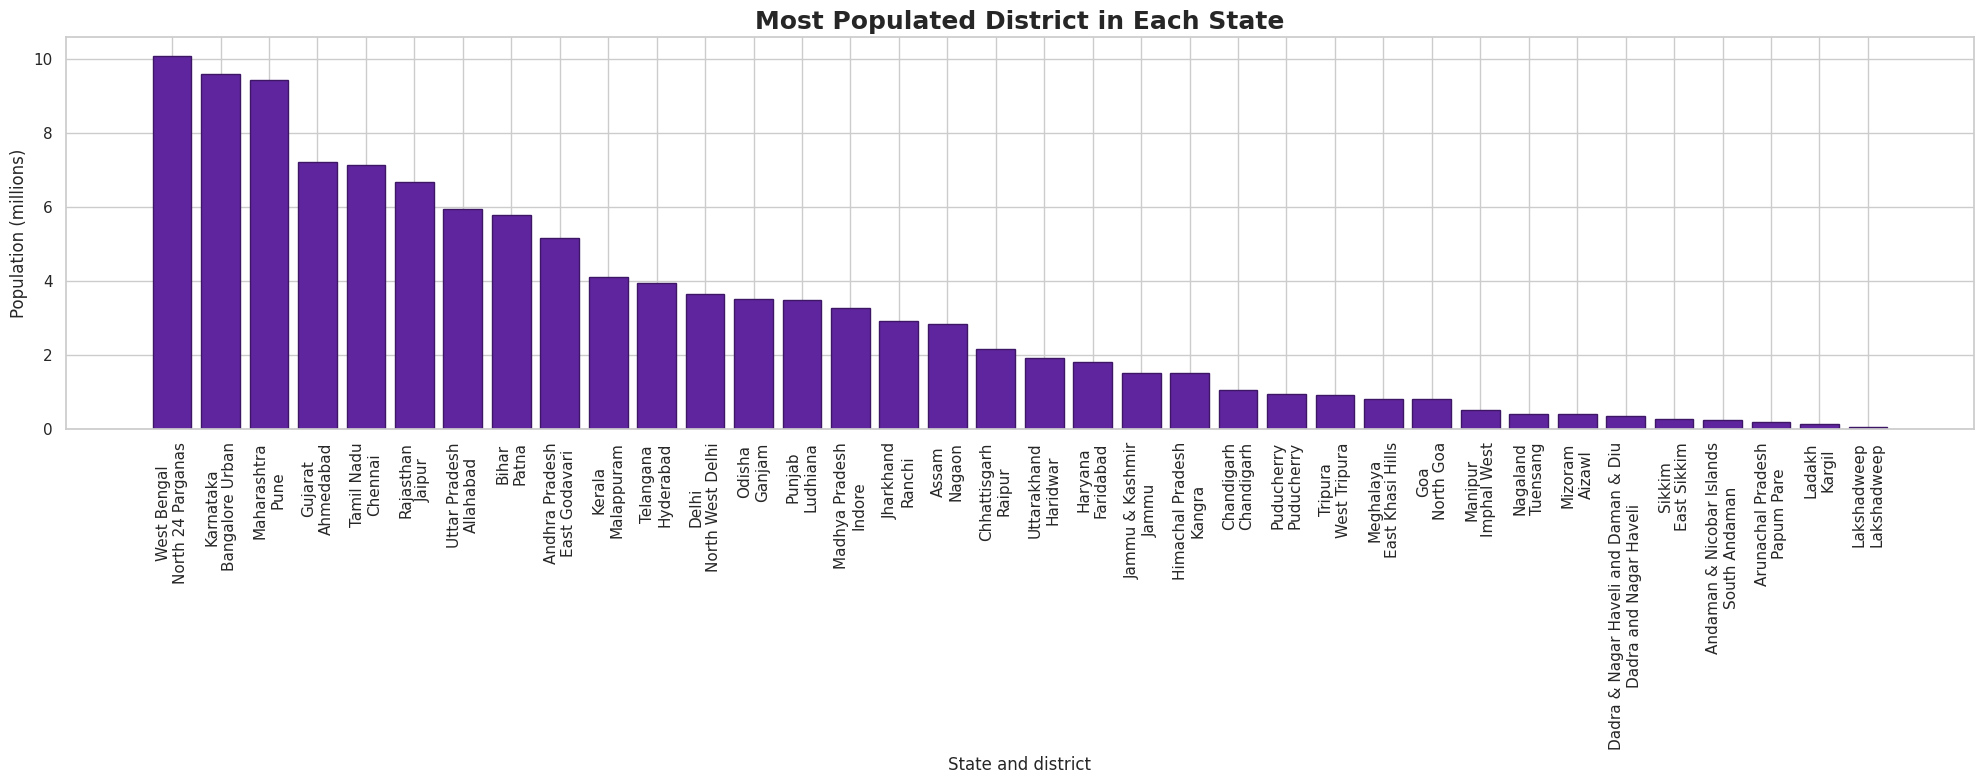

In [41]:
sns.set_theme(style="whitegrid")
chart_data = top_district_population.sort_values(by="Population",ascending=False).copy()
chart_data["State - District"] = chart_data["State"] + "\n" + chart_data["District"]

plt.figure(figsize=(20, 8))
plt.bar(chart_data["State - District"], chart_data["Population"] / 1e6, color=PHONEPE_PURPLE, edgecolor=PHONEPE_DARK_PURPLE)
plt.xlabel("State and district", fontsize=12)
plt.ylabel("Population (millions)", fontsize=12)
plt.title("Most Populated District in Each State", fontsize=18, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()

> **Insights: Most Populated District per State**
>
> - The largest districts are North 24 Parganas in West Bengal (10.1 M), Bangalore Urban in Karnataka (9.6 M), and Pune in Maharashtra (9.4 M).
> - The scale differs greatly: North 24 Parganas has about 10.1 M people, while Lakshadweep has about 64 K.
> - In many states, the most populated district includes a major metropolitan area, such as Bangalore Urban, Pune, Ahmedabad, Chennai, Jaipur, and Hyderabad. However, this is not true everywhere: Malappuram, Ganjam, and East Godavari are large mixed urban-rural districts.
> - The population figures are census-based, so they should be read as relative district sizes rather than current population estimates.

### **Average Transaction Value by State**

Average Transaction Value (ATV) shows the average amount of money involved in one transaction.

**Formula:**  
`ATV = Total Transaction Amount ÷ Total Number of Transactions`

In [42]:
state_atv = txns.groupby("State")[["Transactions","Amount (INR)"]].sum().reset_index()

In [43]:
state_atv["ATV (INR)"] = state_atv["Amount (INR)"] / state_atv["Transactions"]

In [44]:
top_5_atv = state_atv[["State","ATV (INR)"]].sort_values(by="ATV (INR)",ascending=False).reset_index(drop=True).head(5)

In [45]:
bottom_5_atv = state_atv[["State","ATV (INR)"]].sort_values(by="ATV (INR)",ascending=True).reset_index(drop=True).head(5)

In [46]:
print("Top 5 states with the Highest ATV:")
display(top_5_atv[["State", "ATV (INR)"]])

Top 5 states with the Highest ATV:


,State,ATV (INR)
0,Ladakh,"3,514.15"
1,Andaman & Nicobar Islands,"2,976.40"
2,Mizoram,"2,920.85"
3,Manipur,"2,905.76"
4,Nagaland,"2,794.14"


In [47]:
print("top 5 states with the Lowest ATV:")
display(bottom_5_atv[["State", "ATV (INR)"]])

top 5 states with the Lowest ATV:


,State,ATV (INR)
0,Karnataka,"1,463.04"
1,Dadra & Nagar Haveli and Daman & Diu,"1,497.23"
2,Maharashtra,"1,514.29"
3,West Bengal,"1,541.68"
4,Delhi,"1,631.94"


In [48]:
telangana_row = state_atv[state_atv["State"] == "Telangana"]
telangana_atv_val = telangana_row["ATV (INR)"].values[0]
print(f"Telangana Lifetime ATV: ₹{telangana_atv_val:,.2f}")

Telangana Lifetime ATV: ₹1,948.62


### **App Usage Trends**

This section examines how the number of PhonePe app opens changed over time for Andhra Pradesh.

In [49]:
selected_state = "Andhra Pradesh"
state_app_opens =  txns[txns["State"] == selected_state].groupby(["Year", "Quarter"],as_index=False)["App Opens"].sum()
state_app_opens = state_app_opens.sort_values(by=["Year","Quarter"]).reset_index(drop=True)
state_app_opens["Period"] = state_app_opens["Year"].astype(str) + " Q" + state_app_opens["Quarter"].astype(str)
state_app_opens = state_app_opens[state_app_opens["App Opens"] > 0]

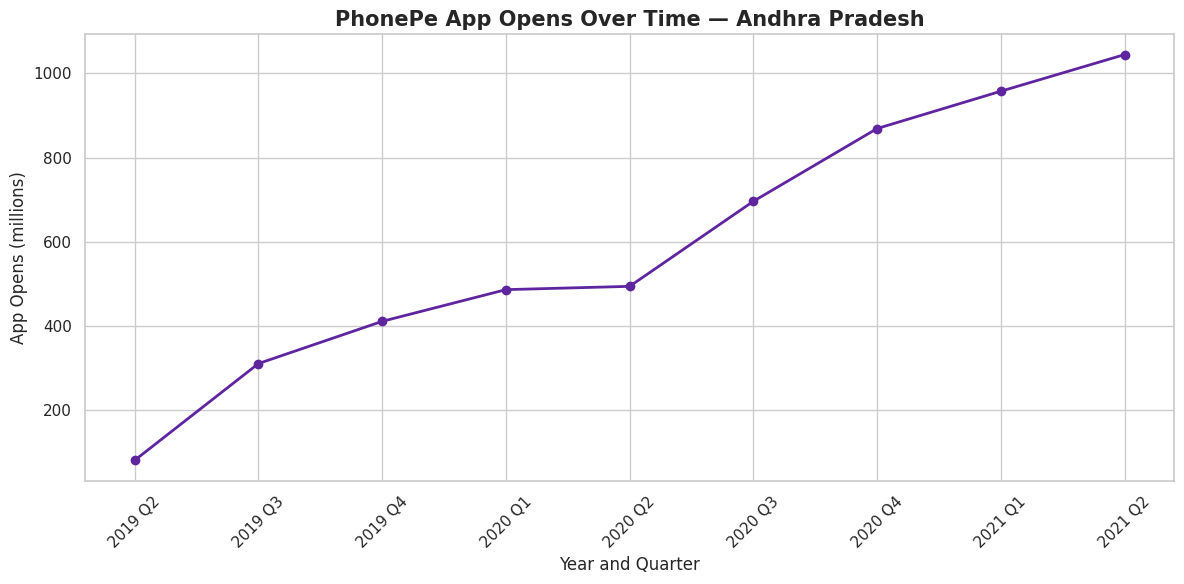

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(state_app_opens["Period"],state_app_opens["App Opens"] / 1_000_000,marker="o",color=PHONEPE_PURPLE,linewidth=2)
plt.title(f"PhonePe App Opens Over Time — {selected_state}",fontsize=15,fontweight="bold")

plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("App Opens (millions)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**

App opens in Andhra Pradesh increased from about 79 million in 2019 Q2 to more than 1 billion in 2021 Q2. The strongest growth appears after 2020 Q2, showing a rapid increase in app engagement during the later part of the dataset.

**Note:** Periods with `0` app opens were excluded from this chart because app-open activity was not recorded for those periods. Treating them as actual zero usage would create a misleading trend.

In [51]:
latest_year = txns_split["Year"].max()
latest_quarter = txns_split[txns_split["Year"] == latest_year]["Quarter"].max()
latest_txn_split = txns_split[(txns_split["Year"] == latest_year) &(txns_split["Quarter"] == latest_quarter)].copy()
type_mix = latest_txn_split.pivot(index = "State",columns="Transaction Type",values="Transactions").fillna(0)
type_mix_pct = type_mix.div(type_mix.sum(axis=1),axis=0)
type_order = ["Merchant payments","Peer-to-peer payments","Recharge & bill payments","Financial Services","Others"]
type_mix_pct = type_mix_pct[type_order]
state_order = type_mix_pct.sort_values(by="Merchant payments",ascending=False).index


In [52]:
TYPE_COLORS = {"Merchant payments": "#5f259f","Peer-to-peer payments": "#f4a259","Recharge & bill payments": "#8d99ae","Financial Services": "#2a9d8f","Others": "#e9c46a"}

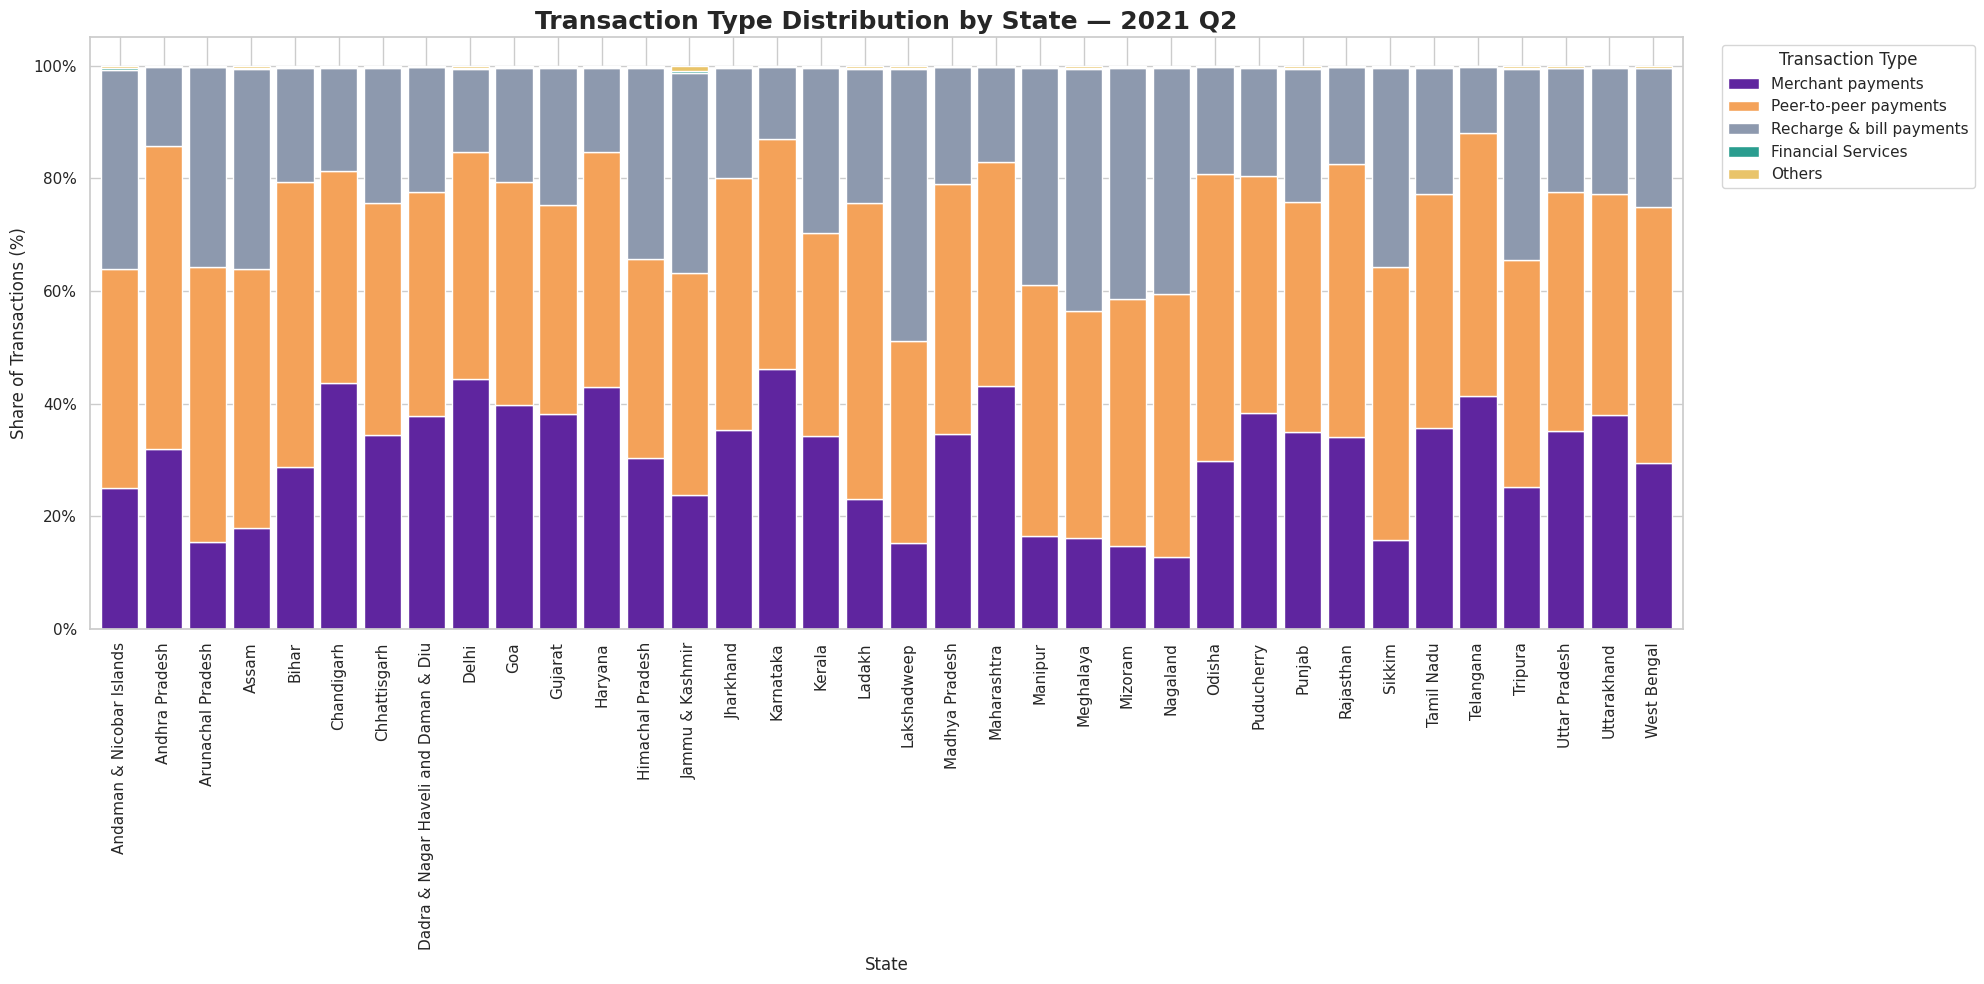

In [53]:
ax = type_mix_pct.plot(kind="bar",stacked=True,figsize=(20,10),color=TYPE_COLORS,width=0.85)
ax.set_title(f"Transaction Type Distribution by State — {latest_year} Q{latest_quarter}",fontsize=18,fontweight="bold")
ax.set_xlabel("State",fontsize=12)
ax.set_ylabel("Share of Transactions (%)",fontsize=12)
ax.legend(title="Transaction Type",loc="upper left",bbox_to_anchor=(1.02,1))
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

> **Insights: Transaction Type Mix by State**
>
> - Merchant-payment share ranges from 46% in Karnataka to 13% in Nagaland. It is also high in Delhi (44%) and Chandigarh (44%).
> - Recharge and bill payments account for a much larger share in Lakshadweep (48%), Meghalaya (43%), and Mizoram (41%).
> - Peer-to-peer payments are a major transaction category in every state, ranging from 35% to 54% of transactions. Andhra Pradesh has the highest peer-to-peer share at 54%.
> - Financial Services and Others together account for at most 1.2% of transactions in every state.

In [54]:
district_code_mapping = district_demo[["State", "District", "Code"]].drop_duplicates().sort_values(by=["State", "District"]).reset_index(drop=True)
district_code_mapping.head(10)

,State,District,Code
0,Andaman & Nicobar Islands,Nicobar,AN01
1,Andaman & Nicobar Islands,North and Middle Andaman,AN02
2,Andaman & Nicobar Islands,South Andaman,AN03
3,Andhra Pradesh,Anantapur,AP01
4,Andhra Pradesh,Chittoor,AP02
5,Andhra Pradesh,East Godavari,AP03
6,Andhra Pradesh,Guntur,AP04
7,Andhra Pradesh,Krishna,AP05
8,Andhra Pradesh,Kurnool,AP06
9,Andhra Pradesh,Prakasam,AP07


In [55]:
print("Is district Code unique?", district_demo["Code"].is_unique)

Is district Code unique? True


The cleaned district code mapping is exported as a CSV file for future use.

In [56]:
district_code_mapping.to_csv("district_code_mapping.csv",index=False)

In [57]:
# from google.colab import files
# files.download("district_code_mapping.csv")

## **Data Consistency Check**

This section checks whether district-level totals match the corresponding state-level totals for transactions, transaction amount, and registered users.

### **State-Level and District-Level Comparison**

For each state, year, and quarter, district-level values are added together and compared with the corresponding state-level values.

In [58]:
district_state_totals = district_txns.groupby(["State","Year","Quarter"],as_index=False)[["Transactions","Amount (INR)","Registered Users"]].sum()
state_totals = txns[["State", "Year", "Quarter","Transactions", "Amount (INR)", "Registered Users"]].copy()
consistency_check = state_totals.merge(district_state_totals,on=["State", "Year", "Quarter"],how="inner",suffixes=("_state", "_district"))
consistency_check["Transactions Difference"] = consistency_check["Transactions_state"]- consistency_check["Transactions_district"]
consistency_check["Amount Difference"] = consistency_check["Amount (INR)_state"]- consistency_check["Amount (INR)_district"]
consistency_check["Registered Users Difference"] = consistency_check["Registered Users_state"]- consistency_check["Registered Users_district"]

consistency_check.head()

,State,Year,Quarter,Transactions_state,Amount (INR)_state,Registered Users_state,Transactions_district,Amount (INR)_district,Registered Users_district,Transactions Difference,Amount Difference,Registered Users Difference
0,Andaman & Nicobar Islands,2018,1,6658,"14,631,761.22",6740,6658,"14,631,761.22",6740,0,-0.00,0
1,Andaman & Nicobar Islands,2018,2,11340,"28,338,535.51",9405,11340,"28,338,535.51",9405,0,-0.00,0
2,Andaman & Nicobar Islands,2018,3,16265,"55,557,471.13",12149,16265,"55,557,471.13",12149,0,0.00,0
3,Andaman & Nicobar Islands,2018,4,23758,"90,548,336.07",15222,23758,"90,548,336.07",15222,0,-0.00,0
4,Andaman & Nicobar Islands,2019,1,30486,"102,299,740.67",18596,30486,"102,299,740.67",18596,0,0.00,0


### **Discrepancy Check**

Rows are flagged only when transaction counts, registered users, or transaction amounts differ meaningfully between the state-level and district-level datasets.

In [59]:
amount_tolerance = 0.10

discrepancies = consistency_check[(consistency_check["Transactions Difference"] != 0) |(consistency_check["Registered Users Difference"] != 0) |(consistency_check["Amount Difference"].abs() > amount_tolerance)]

if discrepancies.empty:
    print("No meaningful discrepancies found between state-level and district-level data.")
else:
    display(discrepancies)

No meaningful discrepancies found between state-level and district-level data.


**Insights:**

District-level totals match the state-level data for transaction counts and registered users across all available state-quarter records. Small transaction-amount differences of up to ₹0.10 were treated as normal floating-point rounding differences.

## **User Penetration by State**

This section compares registered PhonePe users with each state’s population to understand how widely PhonePe is represented across states.

In [60]:
state_users = txns.sort_values(by=["State","Year","Quarter"]).groupby("State",as_index=False)["Registered Users"].last()
state_population = district_demo.groupby("State",as_index=False)["Population"].sum()
user_population_ratio = state_users.merge(state_population,on="State",how="inner")
user_population_ratio["Users to Population Ratio (%)"] = user_population_ratio["Registered Users"] / user_population_ratio["Population"] * 100

In [61]:
ratio_chart_data = user_population_ratio.sort_values(by="Users to Population Ratio (%)",ascending=False).reset_index(drop=True)
latest_year = txns["Year"].max()
latest_quarter = txns[txns["Year"] == latest_year]["Quarter"].max()
national_ratio = user_population_ratio["Registered Users"].sum() / user_population_ratio["Population"].sum() * 100
bar_colors = np.where(ratio_chart_data["Users to Population Ratio (%)"] > national_ratio, PHONEPE_PURPLE,"#B7A2D6")

In [62]:
needed = user_population_ratio.copy()
needed["Users Needed"] = (needed["Population"] * national_ratio / 100 - needed["Registered Users"]).clip(lower=0)
needed[needed["State"].isin(["Uttar Pradesh", "Bihar", "West Bengal"])][["State", "Users to Population Ratio (%)", "Users Needed"]]

,State,Users to Population Ratio (%),Users Needed
4,Bihar,14.42,"10,625,150.59"
33,Uttar Pradesh,15.37,"19,106,644.37"
35,West Bengal,19.37,"4,907,873.97"


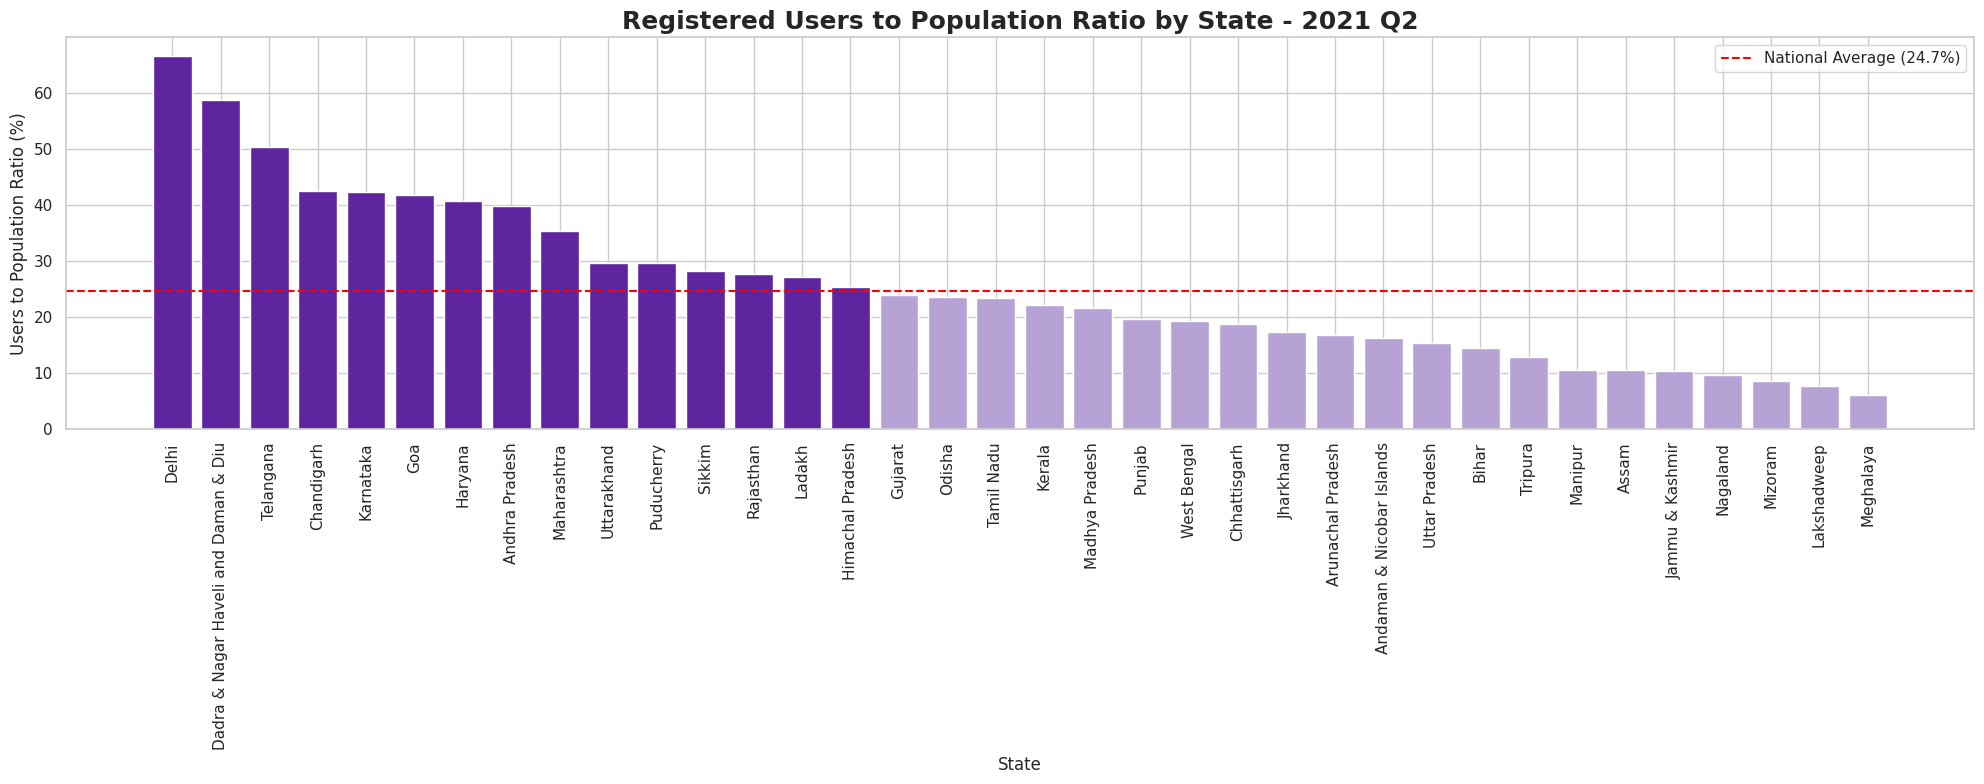

In [63]:
plt.figure(figsize=(20, 8))
plt.bar(ratio_chart_data["State"], ratio_chart_data["Users to Population Ratio (%)"],color=bar_colors)
plt.axhline(national_ratio,color="red",linestyle="--",label=f"National Average ({national_ratio:.1f}%)")
plt.xlabel("State",fontsize=12)
plt.ylabel("Users to Population Ratio (%)",fontsize=12)
plt.title(f"Registered Users to Population Ratio by State - {latest_year} Q{latest_quarter}", fontsize=18, fontweight="bold")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

> **Insights: User-to-Population Ratio**
>
> - The ratio is highest in Delhi (67%), Dadra & Nagar Haveli and Daman & Diu (59%), and Telangana (50%). It is lowest in Mizoram (8%), Lakshadweep (8%), and Meghalaya (6%).
> - Only 15 of 36 states are at or above the national ratio of 24.7%.
>- Uttar Pradesh (15.4%), Bihar (14.4%) and West Bengal (19.4%) are all below the national ratio of 24.7%. Uttar Pradesh and Bihar together account for about 25% of the population in this data, which suggests substantial room for further user growth in these states.

> - **Caveat:** Registered users represent sign-ups rather than necessarily active users, and the population figures are census-based. Therefore, this ratio is an adoption proxy, not an exact measure of current penetration.

## **Population Density and Transaction Activity**

This section examines whether districts with higher population density also tend to have higher PhonePe transaction volume.

In [64]:
district_totals = district_txns.groupby(["State","District","Code"],as_index=False)["Transactions"].sum()
district_alltime = district_totals.merge(district_demo[["State","District","Code","Population","Density"]],on=["State","District","Code"],how="inner")

In [65]:
valid_density_data = district_alltime[district_alltime["Density"] > 0].copy()
density_transaction_correlation = valid_density_data[["Density","Transactions"]].corr(method="spearman")
correlation_value = valid_density_data["Density"].corr(valid_density_data["Transactions"], method="spearman")

print(f"Spearman correlation between population density and transaction volume: {correlation_value:.2f}")

Spearman correlation between population density and transaction volume: 0.42


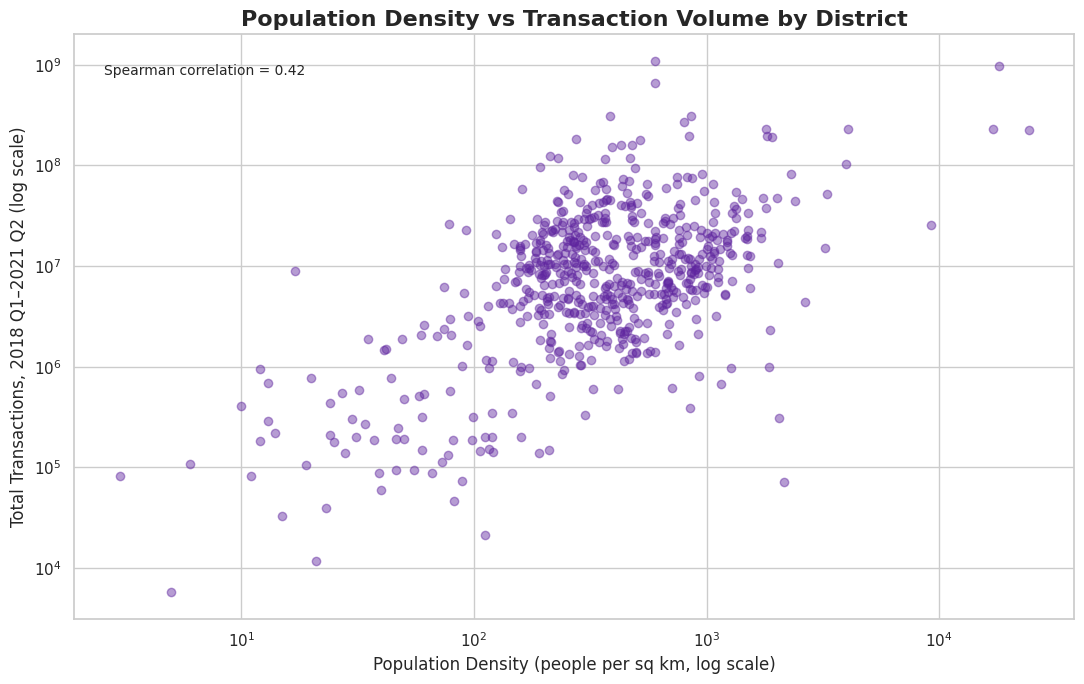

In [66]:
plt.figure(figsize=(11, 7))
plt.scatter(valid_density_data["Density"], valid_density_data["Transactions"],alpha=0.45,color=PHONEPE_PURPLE)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Population Density (people per sq km, log scale)", fontsize=12)
plt.ylabel("Total Transactions, 2018 Q1–2021 Q2 (log scale)", fontsize=12)
plt.title("Population Density vs Transaction Volume by District",fontsize=16,fontweight="bold")
plt.text(0.03,0.95,f"Spearman correlation = {correlation_value:.2f}",transform=plt.gca().transAxes,verticalalignment="top",fontsize=10)


plt.tight_layout()
plt.show()

**Insights: Population Density vs. Transaction Volume**

* **Moderate Positive Correlation:** A Spearman rank correlation of **0.42** points to a moderate positive relationship. While districts with higher population density generally record more transactions, the trend is far less deterministic than it is for overall population size.

* **Density Outliers and Urban Disconnect:** Several districts with very high density sit lower on total transactions, while multiple moderately dense districts generate massive volume. Sheer geographic concentration does not guarantee adoption; commercial infrastructure, retail merchant coverage, and local UPI awareness play a stronger role than how tightly packed residents are.

* **Log-Scale Dynamics:** Applying log scaling to both axes normalizes extreme variations, from sparsely populated mountain and island districts under 100 people per sq km to dense metropolitan pockets exceeding 10,000 per sq km.

## **District Population and Transaction Activity**

This section examines whether districts with larger populations tend to record higher PhonePe transaction volumes.

In [67]:
valid_population_data = district_alltime[district_alltime["Population"] > 0].copy()
population_transaction_correlation = valid_population_data[["Population","Transactions"]].corr(method="spearman")
population_correlation_value = valid_population_data["Population"].corr(valid_population_data["Transactions"], method="spearman")

print(f"Spearman correlation between district population and transaction volume: {population_correlation_value:.2f}")

Spearman correlation between district population and transaction volume: 0.79


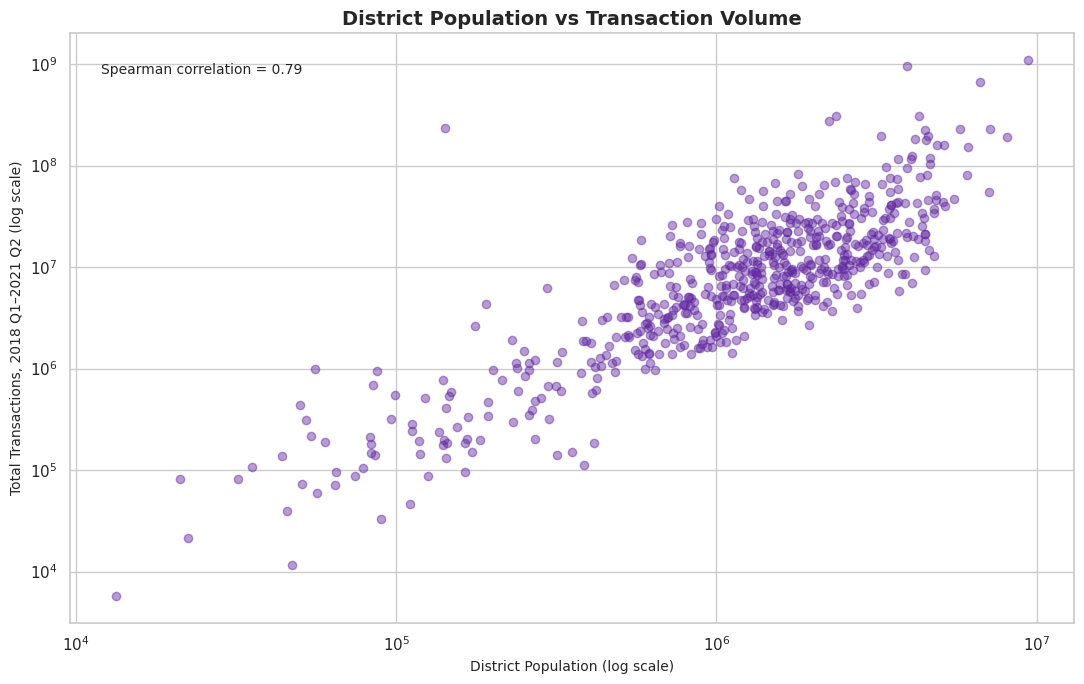

In [68]:
plt.figure(figsize=(11, 7))
plt.scatter(valid_population_data["Population"],valid_population_data["Transactions"],alpha=0.45,color=PHONEPE_PURPLE)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("District Population (log scale)", fontsize=10)
plt.ylabel("Total Transactions, 2018 Q1–2021 Q2 (log scale)", fontsize=10)
plt.title("District Population vs Transaction Volume",fontsize=14,fontweight="bold")
plt.text(0.03,0.95,f"Spearman correlation = {population_correlation_value:.2f}",transform=plt.gca().transAxes,verticalalignment="top",fontsize=10)

plt.tight_layout()
plt.show()

**Insights: District Population vs. Transaction Volume**

* **Strong Positive Correlation:** A Spearman rank correlation of **0.79** confirms a strong monotonic relationship: larger-population districts consistently record higher cumulative PhonePe transaction volumes.

* **Headcount vs. Density:** Total population shows a much stronger association with volume than population density (**0.79 vs. 0.42**), demonstrating that overall market size and addressable users drive payment activity far more than crowded urban density alone.

* **Variance Across Tiers:** While the correlation is strong, the vertical spread across similar district sizes indicates that merchant adoption, localized digital payment infrastructure, and banking access still introduce noticeable performance differences.

## **Transaction Amount per Registered User by State**

This section calculates the total PhonePe transaction amount associated with each registered user across states.

In [69]:
latest_year = txns["Year"].max()
latest_quarter = txns.loc[txns["Year"] == latest_year,"Quarter"].max()
latest_rows = txns[(txns["Year"] == latest_year) &(txns["Quarter"] == latest_quarter)].copy()
latest_rows["Avg Amount per User (INR)"] = (latest_rows["Amount (INR)"] /latest_rows["Registered Users"])
state_average_amount_per_user = latest_rows[["State", "Amount (INR)", "Registered Users", "Avg Amount per User (INR)"]].sort_values(by="Avg Amount per User (INR)",ascending=False).reset_index(drop=True)

state_average_amount_per_user

,State,Amount (INR),Registered Users,Avg Amount per User (INR)
0,Telangana,"1,027,958,332,797.58",18306880,"56,151.48"
1,Andhra Pradesh,"850,737,499,108.25",19620905,"43,358.73"
2,Karnataka,"837,887,151,230.05",25751023,"32,538.01"
3,Rajasthan,"561,702,765,169.24",18980985,"29,592.92"
4,Madhya Pradesh,"425,500,768,035.62",15940935,"26,692.33"
5,Delhi,"281,941,097,684.54",11182699,"25,212.26"
6,Bihar,"374,580,255,186.58",14972134,"25,018.49"
7,Odisha,"245,864,117,477.27",9891029,"24,857.28"
8,Manipur,"7,889,827,962.40",335409,"23,523.01"
9,Maharashtra,"915,115,055,623.70",39664697,"23,071.27"


In [70]:
print(f"Top 5 states — highest transaction amount per user in {latest_year} Q{latest_quarter}:")
display(state_average_amount_per_user[["State", "Avg Amount per User (INR)"]].head(5))

print("\n" * 2)

print(f"Bottom 5 states — lowest transaction amount per user in {latest_year} Q{latest_quarter}:")
display(state_average_amount_per_user[["State", "Avg Amount per User (INR)"]].tail(5).reset_index(drop=True))

Top 5 states — highest transaction amount per user in 2021 Q2:


,State,Avg Amount per User (INR)
0,Telangana,"56,151.48"
1,Andhra Pradesh,"43,358.73"
2,Karnataka,"32,538.01"
3,Rajasthan,"29,592.92"
4,Madhya Pradesh,"26,692.33"





Bottom 5 states — lowest transaction amount per user in 2021 Q2:


,State,Avg Amount per User (INR)
0,Kerala,"10,008.90"
1,Himachal Pradesh,"9,463.11"
2,Dadra & Nagar Haveli and Daman & Diu,"9,152.82"
3,Tripura,"7,345.40"
4,Lakshadweep,"5,593.03"


> **Insights: Transaction Amount per Registered User — 2021 Q2**
>
> - Telangana has the highest transaction amount per registered user at about ₹56,151, followed by Andhra Pradesh (₹43,359).
> - Lakshadweep has the lowest value at about ₹5,593 per registered user.
> - This measure compares transaction value and registered users within the same quarter, making it a fair comparison across states.
> - Higher values can result from more transactions per user, higher-value transactions, or both. It does not mean that every user spent this exact amount.

## **Device Brand Usage Ratio by State**

This section calculates each device brand’s share of registered PhonePe users in every state during the latest available quarter.

In [71]:
latest_device_data = sd[(sd["Year"] == latest_year) &(sd["Quarter"] == latest_quarter)].copy()
latest_state_users = txns[(txns["Year"] == latest_year) &(txns["Quarter"] == latest_quarter)][["State", "Registered Users"]].copy()
device_usage_ratio = latest_device_data.merge(latest_state_users,on="State",how="inner",suffixes=("_brand", "_state"))
device_usage_ratio["Device Brand Usage Ratio (%)"] = (device_usage_ratio["Registered Users_brand"] /device_usage_ratio["Registered Users_state"] * 100)
device_usage_ratio = device_usage_ratio[["State", "Brand", "Registered Users_brand","Registered Users_state", "Device Brand Usage Ratio (%)"]].sort_values(by=["State", "Device Brand Usage Ratio (%)"],ascending=[True, False]).reset_index(drop=True)

device_usage_ratio.head(10)

,State,Brand,Registered Users_brand,Registered Users_state,Device Brand Usage Ratio (%)
0,Andaman & Nicobar Islands,Vivo,15056,62095,24.25
1,Andaman & Nicobar Islands,Xiaomi,14788,62095,23.82
2,Andaman & Nicobar Islands,Samsung,11476,62095,18.48
3,Andaman & Nicobar Islands,Oppo,5456,62095,8.79
4,Andaman & Nicobar Islands,Others,4564,62095,7.35
5,Andaman & Nicobar Islands,Realme,4034,62095,6.50
6,Andaman & Nicobar Islands,OnePlus,1981,62095,3.19
7,Andaman & Nicobar Islands,Huawei,1559,62095,2.51
8,Andaman & Nicobar Islands,Apple,1153,62095,1.86
9,Andaman & Nicobar Islands,Motorola,1054,62095,1.70


In [72]:
device_usage_chart = device_usage_ratio.pivot(index="State",columns="Brand",values="Device Brand Usage Ratio (%)").fillna(0)
device_usage_chart = device_usage_chart.sort_index()
device_usage_chart.head()

Brand,Apple,Asus,Gionee,HMD Global,Huawei,Infinix,Lava,Lenovo,Micromax,Motorola,OnePlus,Oppo,Others,Realme,Samsung,Tecno,Vivo,Xiaomi
State,,,,,,,,,,,,,,,,,,
Andaman & Nicobar Islands,1.86,0.00,0.00,0.00,2.51,0.00,0.00,0.00,0.00,1.70,3.19,8.79,7.35,6.50,18.48,1.57,24.25,23.82
Andhra Pradesh,2.30,0.00,0.00,0.00,2.24,0.00,0.00,1.33,0.00,2.56,2.01,11.08,6.48,9.26,19.36,0.00,18.21,25.17
Arunachal Pradesh,1.87,0.00,0.93,0.00,0.89,0.00,0.00,0.00,0.00,0.82,0.97,15.67,5.42,8.31,18.89,0.00,23.45,22.78
Assam,1.15,1.25,1.15,0.00,1.44,0.00,0.00,0.00,0.00,1.18,0.00,13.92,9.55,9.92,14.45,0.00,20.84,25.14
Bihar,0.00,0.00,0.00,0.00,1.44,1.42,0.00,1.03,0.00,1.43,0.00,12.20,7.66,10.52,19.30,1.05,15.44,28.51


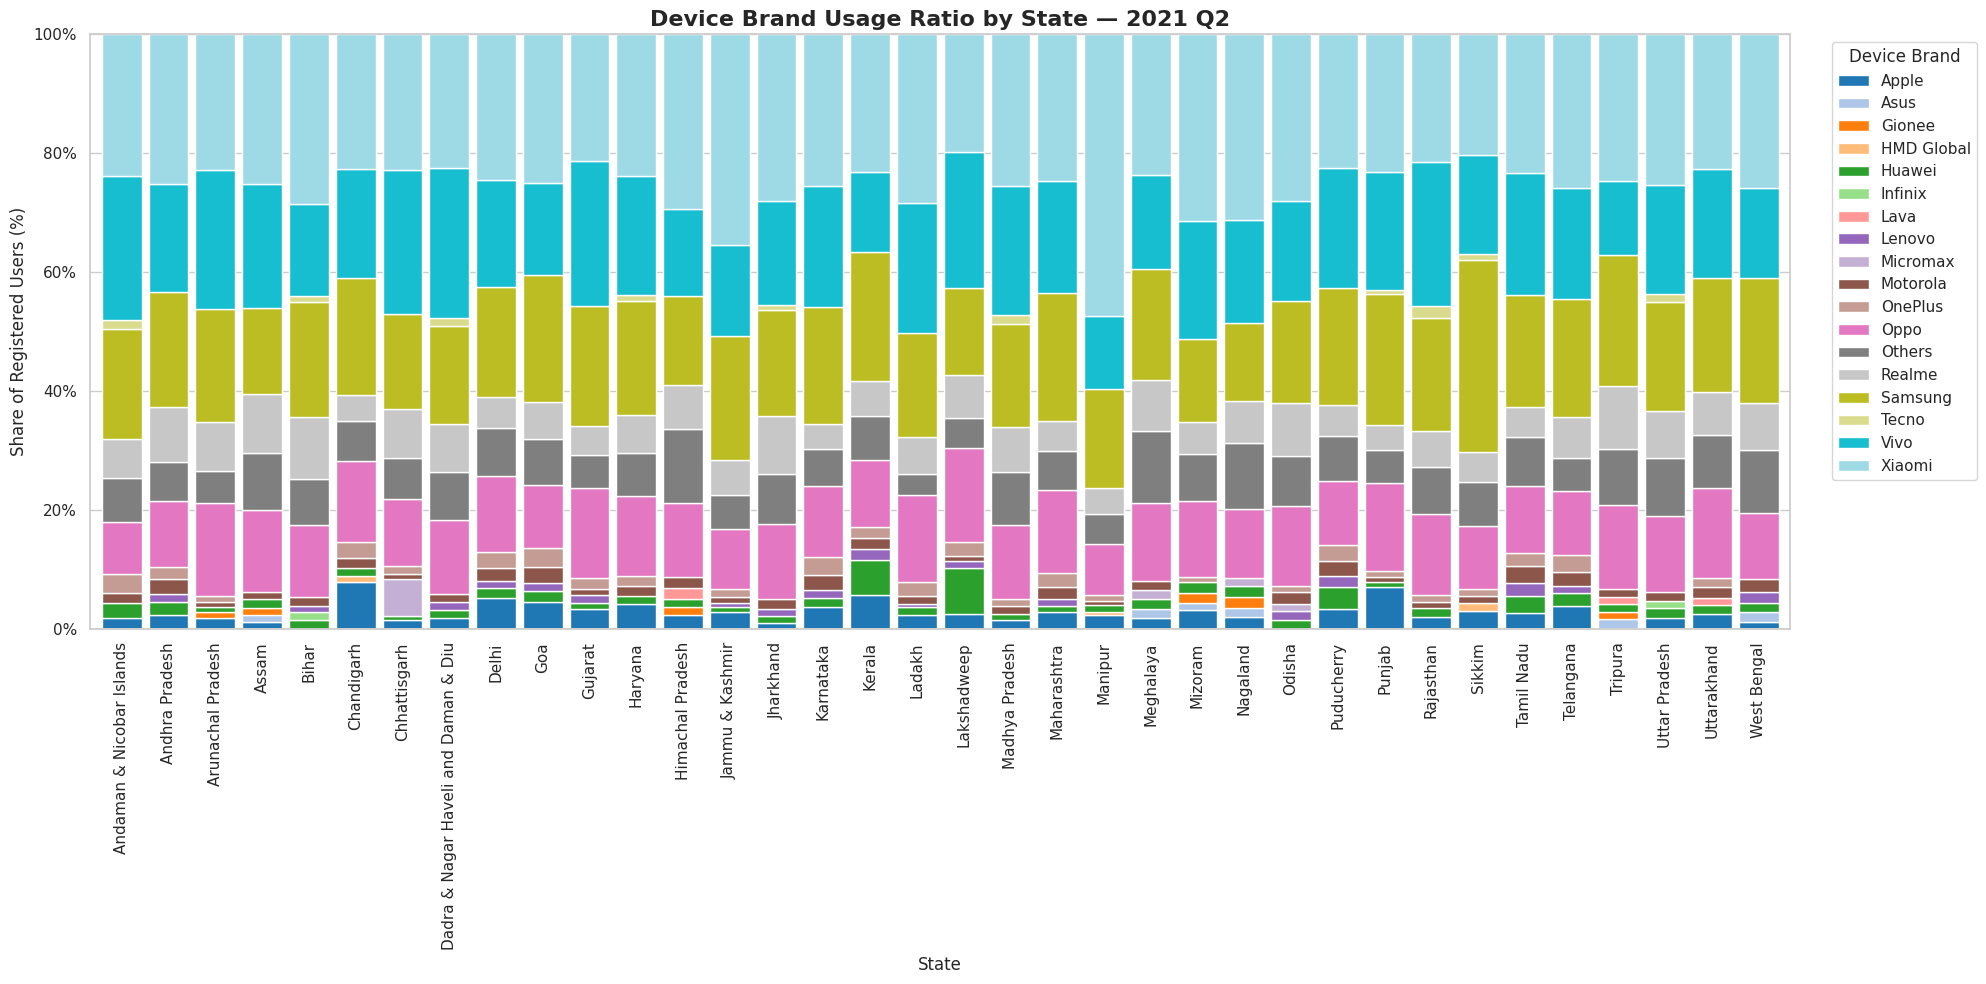

In [73]:
ax = device_usage_chart.plot(kind="bar",stacked=True,figsize=(20,10),colormap="tab20",width=0.85)
ax.set_title(f"Device Brand Usage Ratio by State — {latest_year} Q{latest_quarter}",fontsize=16,fontweight="bold")
ax.set_xlabel("State",fontsize=12)
ax.set_ylabel("Share of Registered Users (%)",fontsize=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.xticks(rotation=90)
plt.legend(title="Device Brand",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

> **Insights: Device Brand Usage Ratio by State — 2021 Q2**
>
> - Device usage is concentrated around Xiaomi, Vivo, Samsung, and Oppo, which form the largest segments in most states.
> - Xiaomi is the leading recorded brand in 28 of 36 states, while Vivo leads in 7 states and Samsung leads in Sikkim.
> - Brand preferences differ across states: no single brand represents all registered PhonePe users in any state.
> - Apple, OnePlus, Motorola, Huawei, and Tecno generally account for smaller shares of registered PhonePe users than Xiaomi, Vivo, Samsung, and Oppo. This describes their representation in this dataset, not their overall market size.
> - Each bar totals 100%, so the chart compares the device mix within each state rather than comparing the total number of users across states.

## **Transactions and Transaction Amount Over Time**

This section compares how PhonePe transaction count and total transaction amount changed over time in Andhra Pradesh.

In [74]:
selected_state = "Andhra Pradesh"
state_trend = txns[txns["State"] == selected_state].groupby(["State","Year","Quarter"],as_index=False)[["Transactions","Amount (INR)"]].sum().reset_index()
state_trend = state_trend.sort_values(by=["Year","Quarter"])
state_trend["Period"] = state_trend["Year"].astype(str) + " Q" + state_trend["Quarter"].astype(str)

In [75]:
state_trend[["State", "Period", "Transactions", "Amount (INR)"]]

,State,Period,Transactions,Amount (INR)
0,Andhra Pradesh,2018 Q1,9039585,"11,996,276,391.82"
1,Andhra Pradesh,2018 Q2,12353918,"22,883,914,272.63"
2,Andhra Pradesh,2018 Q3,25626061,"35,718,044,599.21"
3,Andhra Pradesh,2018 Q4,30759548,"51,473,779,406.84"
4,Andhra Pradesh,2019 Q1,57264522,"83,760,595,917.08"
5,Andhra Pradesh,2019 Q2,56409015,"113,634,518,758.23"
6,Andhra Pradesh,2019 Q3,76288614,"139,447,944,254.79"
7,Andhra Pradesh,2019 Q4,107218103,"200,948,315,488.79"
8,Andhra Pradesh,2020 Q1,127677357,"252,737,214,289.06"
9,Andhra Pradesh,2020 Q2,144917855,"302,583,689,746.56"


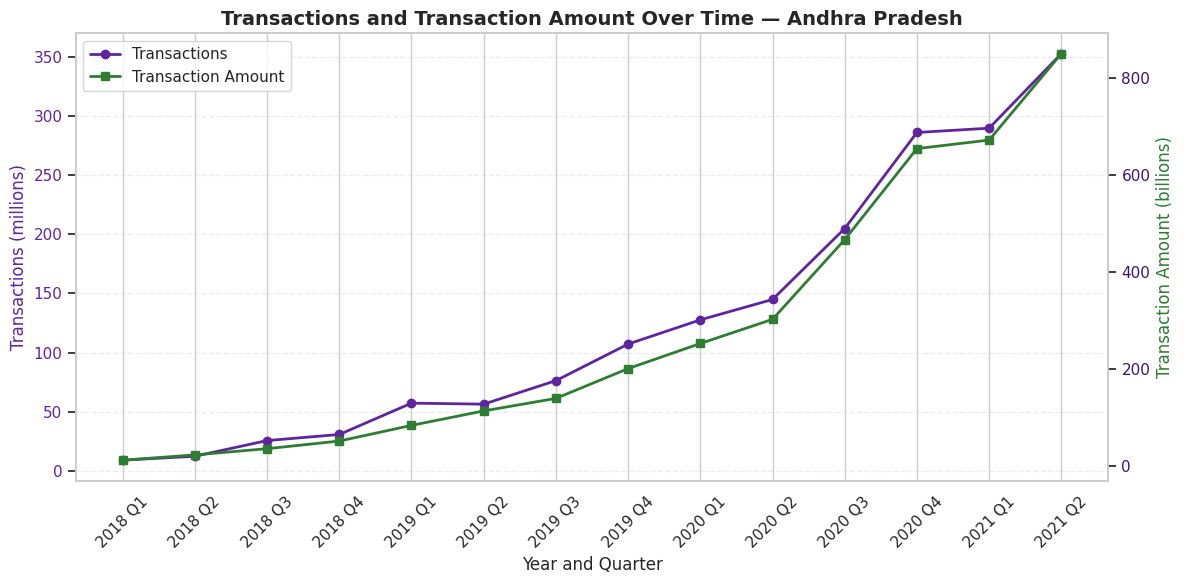

In [76]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Transaction count line
line1 = ax1.plot(state_trend["Period"],state_trend["Transactions"]/1_000_000,marker="o",color=PHONEPE_PURPLE,linewidth=2,label="Transactions")

ax1.set_xlabel("Year and Quarter",fontsize=12)
ax1.set_ylabel("Transactions (millions)", color=PHONEPE_PURPLE,fontsize=12)
ax1.tick_params(axis="y", labelcolor=PHONEPE_PURPLE)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.35)

# Create the right-side axis
ax2 = ax1.twinx()

# Transaction amount line
line2 = ax2.plot(state_trend["Period"],state_trend["Amount (INR)"]/1_000_000_000,marker="s",color=MONEY_GREEN,linewidth=2,label="Transaction Amount (INR)")
ax2.set_ylabel("Transaction Amount (billions)", color=MONEY_GREEN,fontsize=12)
ax2.tick_params(axis="y", labelcolor=PHONEPE_DARK_PURPLE)
ax2.grid(False)

# One combined legend
lines = line1 + line2
ax1.legend(lines,["Transactions", "Transaction Amount"],loc="upper left")
plt.title(f"Transactions and Transaction Amount Over Time — {selected_state}",fontweight="bold",fontsize=14)
plt.tight_layout()
plt.show()

> **Insights: Transactions & Transaction Amount Over Time - Andhra Pradesh**
>
> - In Andhra Pradesh, transactions grew from 9.0 million in 2018 Q1 to 352.8 million in 2021 Q2, about 39 times higher. Transaction amount grew from ₹12 billion to ₹851 billion, about 71 times higher.
> - Transaction amount grew faster than transaction volume, suggesting that the average value of each transaction increased over time—from about ₹1,327 to ₹2,412.
> - Growth was not completely smooth: transactions declined slightly in 2019 Q2 (-1.5%), while 2021 Q1 showed the weakest positive growth (+1.3%).
> - The 2021 Q1 amount was missing in the raw dataset and was recovered during data cleaning. Without this repair, the chart would incorrectly show a sharp fall in transaction amount.

## **Transaction Type Distribution — Andhra Pradesh, 2021 Q2**

This section shows how PhonePe transactions in Andhra Pradesh were distributed across transaction types during 2021 Q2.

In [77]:
selected_state = "Andhra Pradesh"
selected_year = 2021
selected_quarter = 2
pie_data= txns_split[(txns_split["State"] == selected_state) & (txns_split["Year"] == selected_year) & (txns_split["Quarter"] == selected_quarter)].groupby("Transaction Type",as_index=False)["Transactions"].sum().reset_index()
pie_data = pie_data.sort_values(by="Transactions",ascending=False).reset_index(drop=True)
pie_data

,index,Transaction Type,Transactions
0,3,Peer-to-peer payments,189614879
1,1,Merchant payments,112875274
2,4,Recharge & bill payments,49626902
3,2,Others,406842
4,0,Financial Services,243237


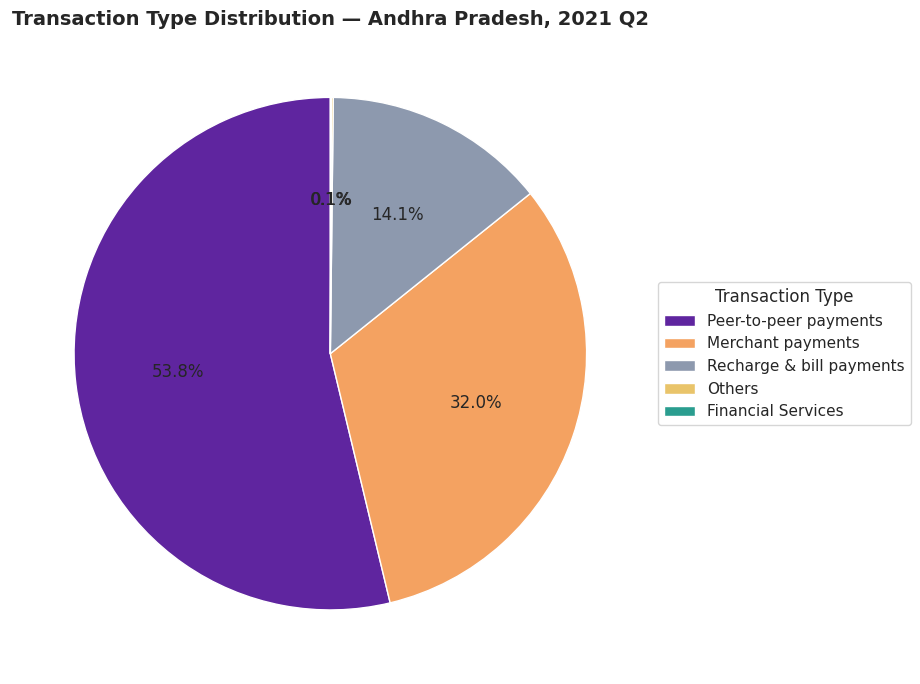

In [78]:
pie_colors = [PHONEPE_PURPLE,"#F4A261","#8D99AE","#E9C46A","#2A9D8F"]
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(pie_data["Transactions"],colors = pie_colors,autopct="%1.1f%%",startangle=90)

ax.legend(wedges,pie_data["Transaction Type"],title="Transaction Type",loc="center left",bbox_to_anchor=(1, 0.5))

ax.set_title(f"Transaction Type Distribution — {selected_state}, "f"{selected_year} Q{selected_quarter}",fontsize=14,fontweight="bold")

plt.tight_layout()
plt.show()

> **Insights: Transaction Type Distribution — Andhra Pradesh, 2021 Q2**
>
> - Peer-to-peer payments made up the largest share at 53.8%, followed by merchant payments at 32.0% and recharge and bill payments at 14.1%.
> - Peer-to-peer payments and merchant payments together accounted for 85.8% of transactions, so most activity came from transfers and merchant purchases.
> - Financial Services and Others made up only a very small share. Their percentage labels are tiny, but the legend identifies both categories.

## **Population Density by District — Andhra Pradesh**

This section compares the population density of districts in Andhra Pradesh.

In [79]:
selected_state = "Andhra Pradesh"
density_data = district_demo[district_demo["State"] == selected_state][["District","Density"]].dropna()
density_data = density_data.sort_values(by="Density",ascending=False).reset_index(drop=True)
density_data

,District,Density
0,Krishna,519
1,West Godavari,490
2,East Godavari,477
3,Srikakulam,462
4,Guntur,429
5,Visakhapatnam,384
6,Vizianagaram,358
7,Chittoor,275
8,Kurnool,229
9,Sri Potti Sriramulu Nellore,227


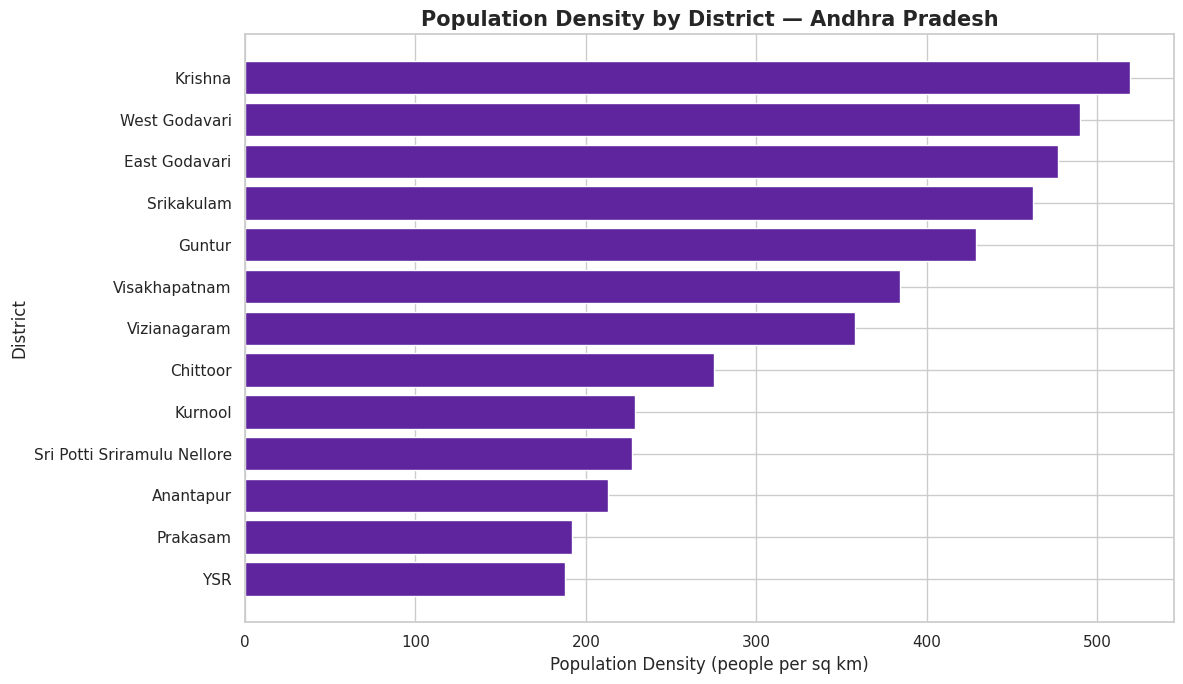

In [80]:
plt.figure(figsize=(12, 7))
plt.barh(density_data["District"],density_data["Density"],color=PHONEPE_PURPLE)
plt.xlabel("Population Density (people per sq km)", fontsize=12)
plt.ylabel("District",fontsize=12)
plt.title(f"Population Density by District — {selected_state}",fontsize=15,fontweight="bold")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Insights: District Population Density — Andhra Pradesh**

* **Density Range & Leaders:** Across the 13 districts, population density ranges from **188 per sq km in YSR** to **519 in Krishna** `~2.8x`. The top three densest districts are **Krishna, West Godavari, and East Godavari**.

* **Density vs. Transactions Disconnect:** Density is a weak predictor of transaction volume. **Visakhapatnam** leads the state with the highest transactions `309 M`, yet its density of **384 per sq km ranks only 6th out of 13**.

* **Context & Alignment:** Density is fairly balanced across the entire state and nowhere near big metro cities like Delhi or Mumbai. Because of this, differences in transaction numbers are driven more by total population size and local business adoption than how crowded an area is.

## **National Transaction Trends**

This section examines how PhonePe transaction activity changes over time and which states contribute the largest share of total transactions.

### **Top States by Transaction Volume**

The chart below ranks the ten states with the most transactions across the full period covered by the dataset. The labels show each state’s percentage of total national transactions.

In [81]:
state_transactions = txns.groupby("State",as_index=False)["Transactions"].sum().sort_values(by="Transactions",ascending=False).reset_index(drop=True)
national_total = state_transactions["Transactions"].sum()
top_10_states = state_transactions.head(10).copy()
top_10_states["Share (%)"] = top_10_states["Transactions"] / national_total * 100
top_10_states["Transactions (billions)"] = top_10_states["Transactions"] / 1_000_000_000
top_10_states

,State,Transactions,Share (%),Transactions (billions)
0,Karnataka,2981044533,14.52,2.98
1,Maharashtra,2833670154,13.80,2.83
2,Telangana,2347430243,11.43,2.35
3,Andhra Pradesh,1781091169,8.67,1.78
4,Rajasthan,1382918930,6.74,1.38
5,Uttar Pradesh,1314714390,6.40,1.31
6,Madhya Pradesh,1100253728,5.36,1.10
7,Delhi,1011031124,4.92,1.01
8,West Bengal,942286041,4.59,0.94
9,Tamil Nadu,800399873,3.90,0.80


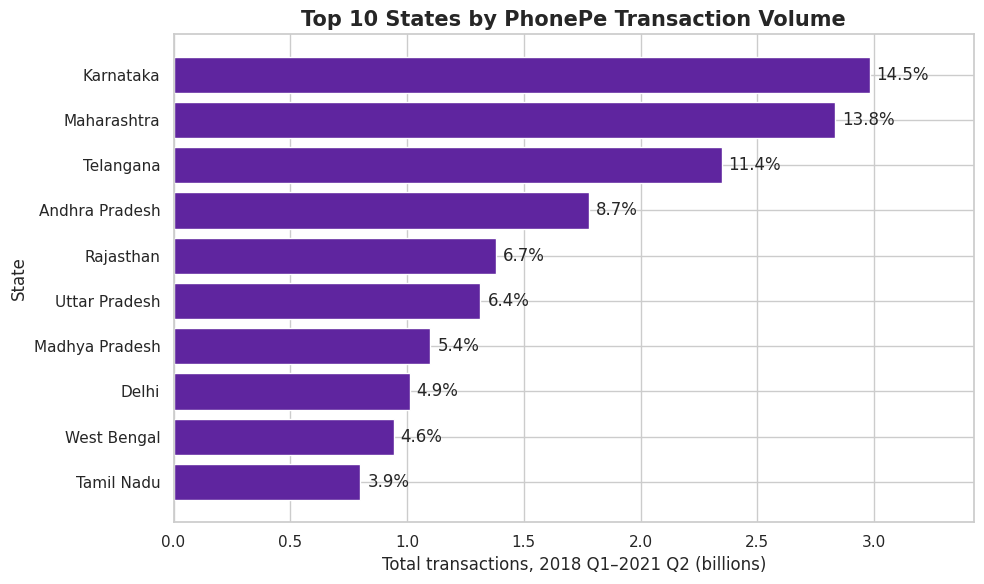

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_10_states["State"],top_10_states["Transactions (billions)"],color=PHONEPE_PURPLE)
ax.bar_label(bars,labels=top_10_states["Share (%)"].map("{:.1f}%".format),padding=5)

ax.set_xlabel("Total transactions, 2018 Q1–2021 Q2 (billions)",fontsize=12)
ax.set_ylabel("State",fontsize=12)
ax.set_title("Top 10 States by PhonePe Transaction Volume", fontweight="bold",fontsize=15)
ax.set_xlim(0, top_10_states["Transactions (billions)"].max() * 1.15)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insights: Transaction volume by state**

* Karnataka contributed the largest share of transactions at **14.5%** (about 2.98 billion), followed by Maharashtra at **13.8%** (about 2.83 billion) and Telangana at **11.4%** (about 2.35 billion).
* Together, these three states account for about **39.7%** of all transactions in the dataset. The top ten account for about **80.3%**, showing that transaction volume is concentrated in a relatively small group of states.
* The top four are all in the South and West of India. The five smallest markets (Lakshadweep, Andaman & Nicobar Islands, Ladakh, Mizoram, Meghalaya) add up to only **0.05%** of volume.
* Telangana ranks **#1** by transaction amount (**₹4.57 T**) but **#3** by transaction count. Its lifetime average transaction value is about **₹1,949**, which explains why its rank by amount is higher than its rank by count.

## **Transaction Trends Over Time**

This section examines how transaction activity and transaction types changed across the dataset

### **Quarterly Transactions and Average Transaction Value**

In [83]:
overall_trend = txns.groupby(["Year","Quarter"],as_index=False)[["Transactions","Amount (INR)"]].sum().sort_values(["Year","Quarter"]).reset_index(drop=True)
overall_trend["Avg Transaction Value (INR)"] = overall_trend["Amount (INR)"] / overall_trend["Transactions"]
overall_trend["Period"] = overall_trend["Year"].astype(str) + " Q" + overall_trend["Quarter"].astype(str)
overall_trend["Transactions (billions)"] = overall_trend["Transactions"] / 1_000_000_000
overall_trend["Transaction Growth (%)"] = overall_trend["Transactions"].pct_change() * 100
overall_trend

,Year,Quarter,Transactions,Amount (INR),Avg Transaction Value (INR),Period,Transactions (billions),Transaction Growth (%)
0,2018,1,134425599,"171,833,431,017.28","1,278.28",2018 Q1,0.13,NaN
1,2018,2,187365440,"304,374,211,667.25","1,624.49",2018 Q2,0.19,39.38
2,2018,3,341299764,"475,101,505,615.09","1,392.04",2018 Q3,0.34,82.16
3,2018,4,417111607,"671,736,248,114.28","1,610.45",2018 Q4,0.42,22.21
4,2019,1,708992981,"990,021,362,110.72","1,396.38",2019 Q1,0.71,69.98
5,2019,2,815380896,"1,354,214,037,092.48","1,660.84",2019 Q2,0.82,15.01
6,2019,3,1095009675,"1,672,558,991,160.43","1,527.44",2019 Q3,1.10,34.29
7,2019,4,1460443663,"2,259,893,742,825.30","1,547.40",2019 Q4,1.46,33.37
8,2020,1,1623038046,"2,697,112,477,804.36","1,661.77",2020 Q1,1.62,11.13
9,2020,2,1448608890,"2,646,145,107,972.51","1,826.68",2020 Q2,1.45,-10.75


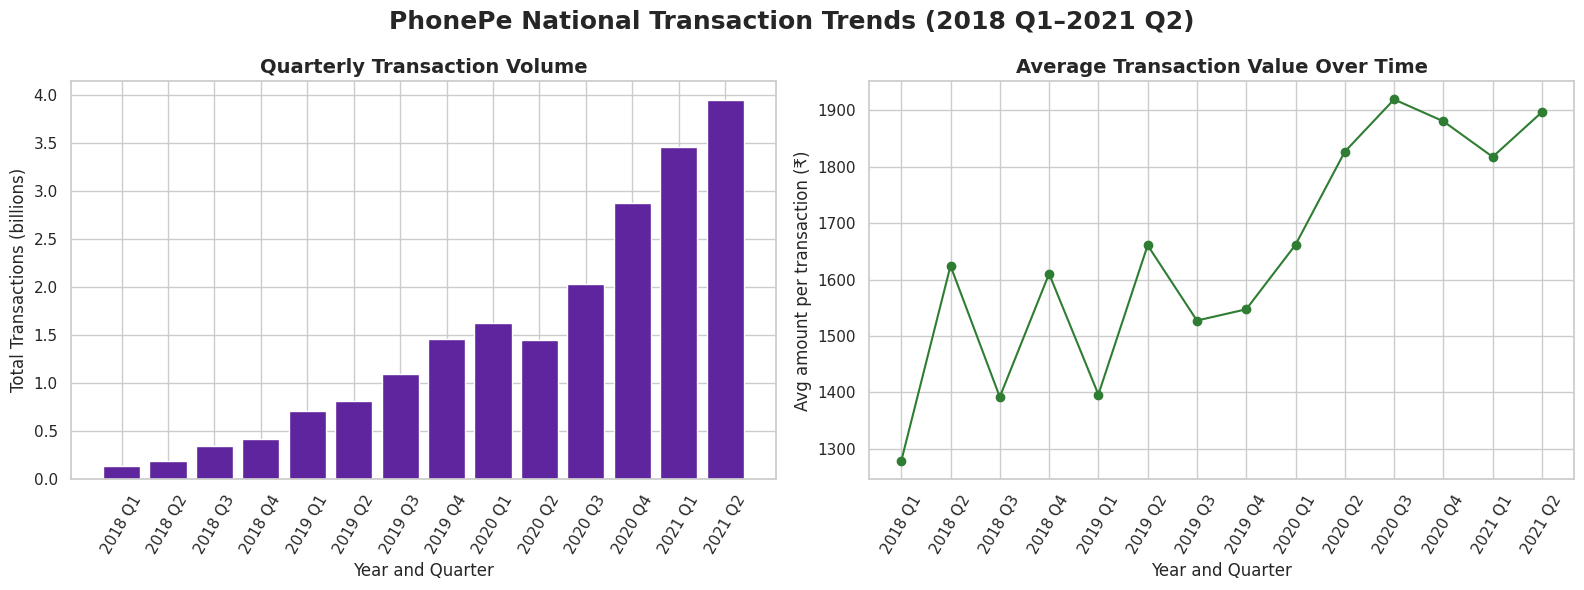

In [84]:
fig,axes = plt.subplots(1,2,figsize = (16,6))
axes[0].bar(overall_trend["Period"],overall_trend["Transactions (billions)"],color=PHONEPE_PURPLE)
axes[0].set_title("Quarterly Transaction Volume", fontweight="bold",fontsize=14)
axes[0].set_xlabel("Year and Quarter",fontsize=12)
axes[0].set_ylabel("Total Transactions (billions)",fontsize=12)
axes[0].tick_params(axis="x",rotation=60)
axes[0].set_axisbelow(True)

axes[1].plot(overall_trend["Period"],overall_trend["Avg Transaction Value (INR)"],marker="o",color=MONEY_GREEN)
axes[1].set_title("Average Transaction Value Over Time", fontweight="bold",fontsize=14)
axes[1].set_xlabel("Year and Quarter",fontsize=12)
axes[1].set_ylabel("Avg amount per transaction (₹)",fontsize=12)
axes[1].tick_params(axis="x",rotation=60)
axes[1].set_axisbelow(True)

fig.suptitle( "PhonePe National Transaction Trends (2018 Q1–2021 Q2)",fontweight="bold",fontsize=18)
plt.tight_layout()
plt.show()


**Insights: PhonePe National Transaction Trends (2018 Q1–2021 Q2)**

* **Strong overall growth:** Quarterly transactions rose from **134 million** in 2018 Q1 to **3.94 billion** in 2021 Q2—about **29 times** the starting volume.
* **A temporary dip in 2020 Q2:** Transactions fell **10.75%**, from **1.62 billion** in 2020 Q1 to **1.45 billion**. This coincided with the national lockdown period, but the chart alone cannot establish the cause.
* **Rebound and continued growth:** Transactions rose **40.35%** in 2020 Q3 and **41.13%** in 2020 Q4. They continued to increase through 2021 Q2, though quarterly growth varied.
* **Higher average transaction value:** ATV rose from **₹1,278** in 2018 Q1 to **₹1,897** in 2021 Q2. It peaked at about **₹1,919** in 2020 Q3 and then fluctuated around ₹1,800–₹1,900.
* **Interpretation:** The higher ATV shows that the average transaction amount increased. This chart does not identify which transaction types drove that change; the transaction-type trend can help explore that separately.

### **Transaction Type Share by Quarter**

In [85]:
quarterly_type_totals = txns_split.groupby(["Year","Quarter","Transaction Type"],as_index=False)["Transactions"].sum()
quarterly_type_mix = quarterly_type_totals.pivot_table(index=["Year","Quarter"],columns="Transaction Type",values="Transactions").fillna(0).sort_index()
quarterly_type_share = quarterly_type_mix.div(quarterly_type_mix.sum(axis=1),axis=0)*100
quarterly_type_share = quarterly_type_share.reset_index()
quarterly_type_share["Period"] = quarterly_type_share["Year"].astype(str) + " Q" + quarterly_type_share["Quarter"].astype(str)
quarterly_type_share = quarterly_type_share.sort_values("Period").set_index("Period").drop(columns=["Year","Quarter"])
quarterly_type_share.columns.name = None
quarterly_type_share.index.name = "Quarter"
quarterly_type_share.reset_index().round(1)

,Quarter,Financial Services,Merchant payments,Others,Peer-to-peer payments,Recharge & bill payments
0,2018 Q1,2.80,4.00,4.30,35.00,54.00
1,2018 Q2,2.80,5.70,2.70,39.80,49.10
2,2018 Q3,1.80,7.40,1.60,59.20,30.00
3,2018 Q4,1.30,17.10,2.00,48.00,31.60
4,2019 Q1,0.70,15.60,1.20,57.10,25.50
5,2019 Q2,0.30,25.30,1.40,47.20,25.70
6,2019 Q3,0.30,34.40,1.30,42.20,21.90
7,2019 Q4,0.20,31.30,0.90,48.20,19.50
8,2020 Q1,0.10,34.90,0.60,42.80,21.60
9,2020 Q2,0.10,25.10,0.30,43.60,31.00


In [86]:
fs_alltime = (txns_split[txns_split["Transaction Type"] == "Financial Services"]["Transactions"].sum() / txns_split["Transactions"].sum()) * 100


latest_mask = (txns_split["Year"] == latest_year) & (txns_split["Quarter"] == latest_quarter)
fs_latest = (txns_split[latest_mask & (txns_split["Transaction Type"] == "Financial Services")]["Transactions"].sum() / txns_split[latest_mask]["Transactions"].sum()) * 100

print(f"Financial Services all-time share: {fs_alltime:.2f}%")
print(f"Financial Services 2021 Q2 share: {fs_latest:.2f}%")

Financial Services all-time share: 0.23%
Financial Services 2021 Q2 share: 0.09%


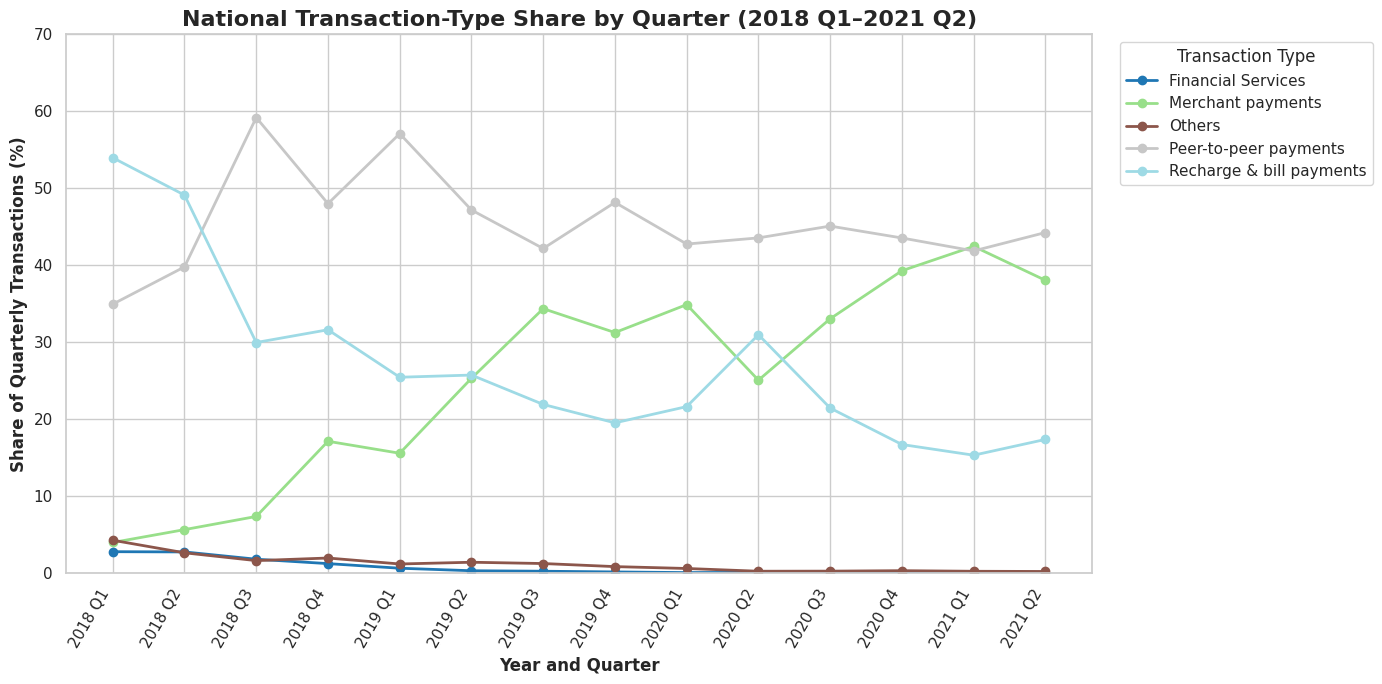

In [87]:
ax = quarterly_type_share.plot(kind="line",marker="o",figsize=(14,7),linewidth=2,colormap="tab20")
ax.set_title("National Transaction-Type Share by Quarter (2018 Q1–2021 Q2)",fontweight="bold",fontsize=16)
ax.set_xlabel("Year and Quarter",fontsize=12,fontweight='bold')
ax.set_ylabel("Share of Quarterly Transactions (%)",fontsize=12,fontweight='bold')
ax.set_ylim(0,70)
ax.tick_params(axis="x", rotation=45)
ax.set_xticks(range(len(quarterly_type_share.index)))
ax.set_xticklabels(quarterly_type_share.index, rotation=60, ha="right")
ax.set_axisbelow(True)
ax.legend(title="Transaction Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Insights: Transaction Type Share by Quarter (2018 Q1–2021 Q2)**

* **Changing transaction mix:** In 2018 Q1, Recharge & bill payments made up **54.0%** of transactions, while Merchant payments made up **4.0%**. By 2021 Q2, Merchant payments had risen to **38.0%**, and Recharge & bill payments had fallen to **17.4%**—a substantial shift in the mix toward merchant payments.
* **Peer-to-peer remained substantial:** P2P reached **59.2%** in 2018 Q3. From 2020 Q1 onward, its share stayed between **41.9% and 45.1%**. It was the largest category in most quarters, although Merchant payments narrowly surpassed it in 2021 Q1.
* **A notable change in 2020 Q2:** Merchant payments’ share fell from **34.9%** in 2020 Q1 to **25.1%** in 2020 Q2, while Recharge & bill payments rose from **21.6%** to **31.0%**. This coincided with the lockdown period, but the chart alone cannot establish the cause.
* **Merchant-share recovery:** After 2020 Q2, Merchant payments’ share rose to a peak of **42.5%** in 2021 Q1, then eased to **38.0%** in 2021 Q2.
* **Smaller categories:** Financial Services and Others each accounted for less than **5%** in every quarter and together made up only **0.3%** in 2021 Q2.

## **Demographic Factors and Transaction Activity**

This section explores how state-level demographic measures relate to PhonePe transaction activity in the latest quarter.

### **Preparing State-Level Measures**


In [88]:
latest_state_txns = txns[(txns["Year"] == latest_year) & (txns["Quarter"] == latest_quarter)][["State", "Transactions", "Amount (INR)", "Registered Users", "App Opens"]].copy()
state_population = district_demo.groupby("State",as_index=False)["Population"].sum()
state_analysis = latest_state_txns.merge(state_population,on="State",how="inner")
state_analysis["Users to Population Ratio (%)"] = state_analysis["Registered Users"] / state_analysis["Population"] * 100
state_analysis["Avg Transaction Value (INR)"] = state_analysis["Amount (INR)"] / state_analysis["Transactions"]
state_analysis["Transactions per Capita"] = state_analysis["Transactions"] / state_analysis["Population"]
state_analysis["App Opens per Registered User"] = state_analysis["App Opens"] / state_analysis["Registered Users"]
state_analysis.head()



,State,Transactions,Amount (INR),Registered Users,App Opens,Population,Users to Population Ratio (%),Avg Transaction Value (INR),Transactions per Capita,App Opens per Registered User
0,Andaman & Nicobar Islands,341414,"899,147,016.11",62095,2248223,380581,16.32,"2,633.60",0.90,36.21
1,Andhra Pradesh,352767134,"850,737,499,108.25",19620905,1044705436,49378776,39.74,"2,411.61",7.14,53.24
2,Arunachal Pradesh,1568338,"4,456,425,616.99",270572,13025849,1606047,16.85,"2,841.50",0.98,48.14
3,Assam,25432905,"59,192,473,376.66",3617056,102003890,34461385,10.50,"2,327.40",0.74,28.20
4,Bihar,155603622,"374,580,255,186.58",14972134,371198660,103817951,14.42,"2,407.27",1.50,24.79


In [89]:
latest_state_type_totals = txns_split[(txns_split["Year"] == latest_year) & (txns_split["Quarter"] == latest_quarter)].groupby(["State","Transaction Type"],as_index=False)["Transactions"].sum()
latest_state_type_mix = latest_state_type_totals.pivot_table(index="State",columns="Transaction Type",values="Transactions").fillna(0)
latest_state_type_share = latest_state_type_mix.div(latest_state_type_mix.sum(axis=1),axis=0)*100
latest_state_type_share = latest_state_type_share.add_suffix(" Share (%)").reset_index()
state_analysis = state_analysis.merge(latest_state_type_share,on="State",how="inner")
state_analysis.head()

,State,Transactions,Amount (INR),Registered Users,App Opens,Population,Users to Population Ratio (%),Avg Transaction Value (INR),Transactions per Capita,App Opens per Registered User,Financial Services Share (%),Merchant payments Share (%),Others Share (%),Peer-to-peer payments Share (%),Recharge & bill payments Share (%)
0,Andaman & Nicobar Islands,341414,"899,147,016.11",62095,2248223,380581,16.32,"2,633.60",0.90,36.21,0.28,24.94,0.48,38.89,35.41
1,Andhra Pradesh,352767134,"850,737,499,108.25",19620905,1044705436,49378776,39.74,"2,411.61",7.14,53.24,0.07,32.00,0.12,53.75,14.07
2,Arunachal Pradesh,1568338,"4,456,425,616.99",270572,13025849,1606047,16.85,"2,841.50",0.98,48.14,0.10,15.52,0.24,48.65,35.49
3,Assam,25432905,"59,192,473,376.66",3617056,102003890,34461385,10.50,"2,327.40",0.74,28.20,0.20,17.94,0.37,45.88,35.62
4,Bihar,155603622,"374,580,255,186.58",14972134,371198660,103817951,14.42,"2,407.27",1.50,24.79,0.10,28.72,0.27,50.57,20.34


### **State-Level Correlation Analysis**

This analysis checks whether demographic measures and PhonePe activity tend to move together across states in the latest quarter. Correlation shows association, not cause.

In [90]:
state_corr_data = state_analysis[[
        "Population",
        "Transactions",
        "Users to Population Ratio (%)",
        "Avg Transaction Value (INR)",
        "Transactions per Capita",
        "App Opens per Registered User",
        "Financial Services Share (%)",
        "Merchant payments Share (%)",
        "Others Share (%)",
        "Peer-to-peer payments Share (%)",
        "Recharge & bill payments Share (%)"]
].rename(columns={
    "Users to Population Ratio (%)": "User penetration (%)",
    "Avg Transaction Value (INR)": "Average transaction value (₹)",
    "Transactions per Capita": "Transactions per capita",
    "App Opens per Registered User": "App opens per user",
    "Financial Services Share (%)": "Financial services (%)",
    "Merchant payments Share (%)": "Merchant payments (%)",
    "Others Share (%)": "Others (%)",
    "Peer-to-peer payments Share (%)": "P2P payments (%)",
    "Recharge & bill payments Share (%)": "Recharge and bills (%)"
})

state_spearman_corr = state_corr_data.corr(method="spearman")
state_spearman_corr.round(2)

,Population,Transactions,User penetration (%),Average transaction value (₹),Transactions per capita,App opens per user,Financial services (%),Merchant payments (%),Others (%),P2P payments (%),Recharge and bills (%)
Population,1.00,0.90,0.07,-0.31,0.36,0.13,-0.54,0.36,-0.34,0.23,-0.45
Transactions,0.90,1.00,0.44,-0.48,0.69,0.15,-0.75,0.63,-0.48,0.20,-0.75
User penetration (%),0.07,0.44,1.00,-0.62,0.91,-0.06,-0.58,0.79,-0.43,-0.08,-0.80
Average transaction value (₹),-0.31,-0.48,-0.62,1.00,-0.61,0.38,0.40,-0.79,0.29,0.49,0.54
Transactions per capita,0.36,0.69,0.91,-0.61,1.00,0.11,-0.81,0.82,-0.60,0.10,-0.92
App opens per user,0.13,0.15,-0.06,0.38,0.11,1.00,-0.31,-0.25,-0.39,0.58,-0.10
Financial services (%),-0.54,-0.75,-0.58,0.40,-0.81,-0.31,1.00,-0.59,0.70,-0.35,0.80
Merchant payments (%),0.36,0.63,0.79,-0.79,0.82,-0.25,-0.59,1.00,-0.31,-0.32,-0.83
Others (%),-0.34,-0.48,-0.43,0.29,-0.60,-0.39,0.70,-0.31,1.00,-0.38,0.56
P2P payments (%),0.23,0.20,-0.08,0.49,0.10,0.58,-0.35,-0.32,-0.38,1.00,-0.18


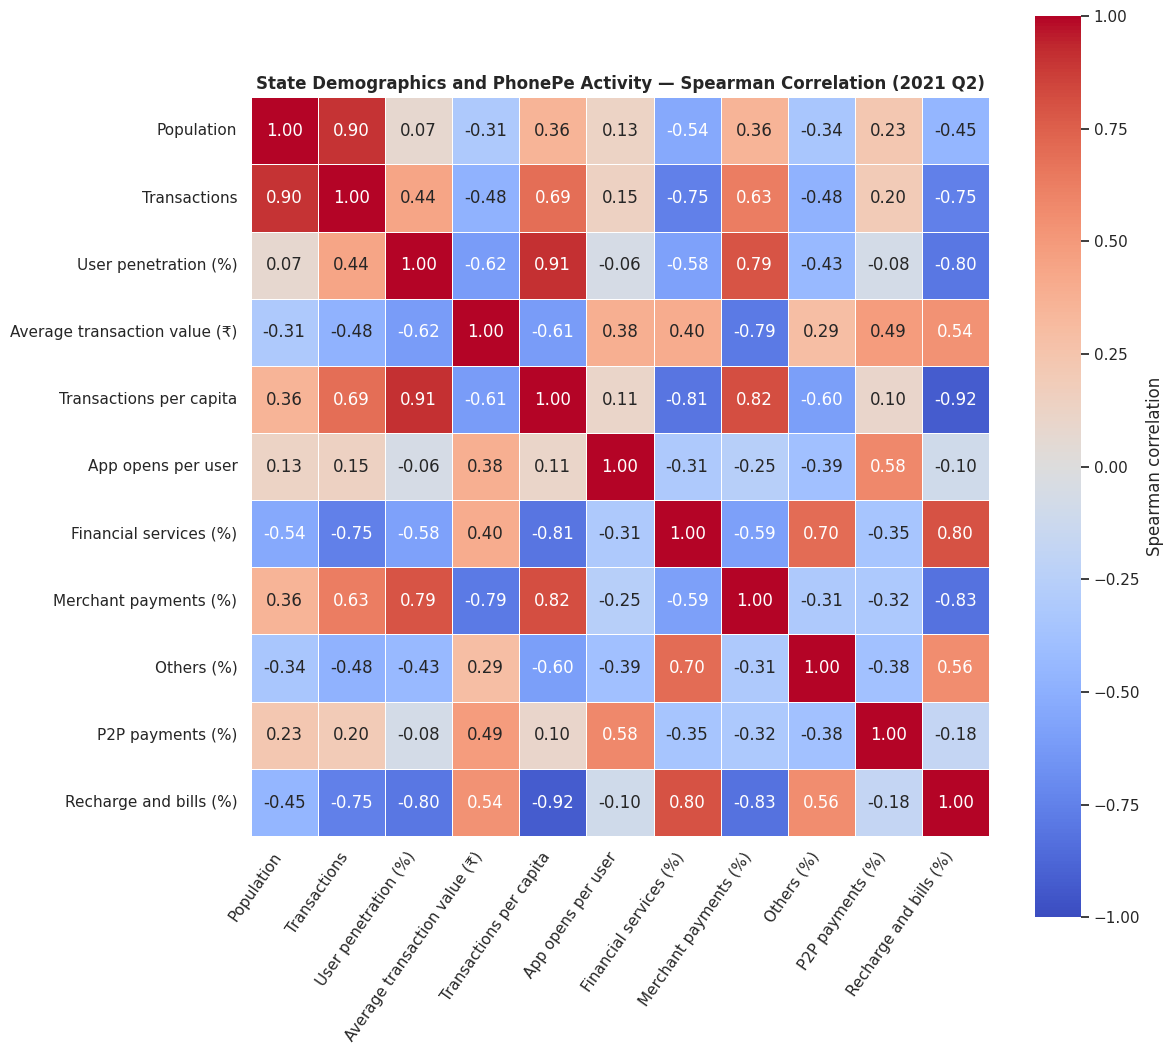

In [91]:
plt.figure(figsize=(12,11))
sns.heatmap(state_spearman_corr,annot=True,cmap="coolwarm",fmt=".2f",center=0,vmin=-1,vmax=1,linewidth=0.5,square=True, cbar_kws={"label": "Spearman correlation"})
plt.title("State Demographics and PhonePe Activity — Spearman Correlation (2021 Q2)",fontweight="bold")
plt.xticks(rotation=55, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights: State Demographics and PhonePe Activity — Spearman Correlation (2021 Q2)**

- **Population and transaction scale:** Population has a strong positive association with raw transaction count (**ρ = 0.90**), but almost no association with user penetration (**ρ = 0.07**). Larger-population states tended to have more transactions overall, but population alone did not indicate a higher registered-user-to-population ratio.
- **Transaction activity and mix:** Transactions per capita are positively associated with Merchant payments share (**ρ = 0.82**) and negatively associated with Recharge & bill payments share (**ρ = -0.92**). In this quarter, states with more transactions per person tended to have a larger merchant-payment share and a smaller recharge-and-bill share. This does not establish which factor drives the other.
- **Average transaction value:** ATV is negatively associated with Merchant payments share (**ρ = -0.79**) and Transactions per capita (**ρ = -0.61**), and positively associated with Recharge & bill payments share (**ρ = 0.54**). These are cross-state patterns; the correlation alone cannot explain why the averages differ.
- **App opens:** App opens per registered user have weak associations with total transactions (**ρ = 0.15**), user penetration (**ρ = -0.06**), and transactions per capita (**ρ = 0.11**). In this state-level comparison, app opens per user do not closely track those measures.
- **Scope and caution:** These are Spearman correlations across **36 states for one quarter**. They describe associations, not causes. Transaction-type shares also add up to 100%, so relationships among those shares are interdependent.

### **Merchant Payment Share and State-Level Outcomes**

This section compares each state’s merchant-payment share with its average transaction value and registered-user-to-population ratio in 2021 Q2. Each point represents one state. The plots help visualize the relationships shown in the correlation heatmap; they do not establish cause and effect.

In [92]:
merchant_atv_spearman = state_analysis["Merchant payments Share (%)"].corr(state_analysis["Avg Transaction Value (INR)"],method="spearman")
merchant_penetration_spearman = state_analysis["Merchant payments Share (%)"].corr(state_analysis["Users to Population Ratio (%)"],method="spearman")

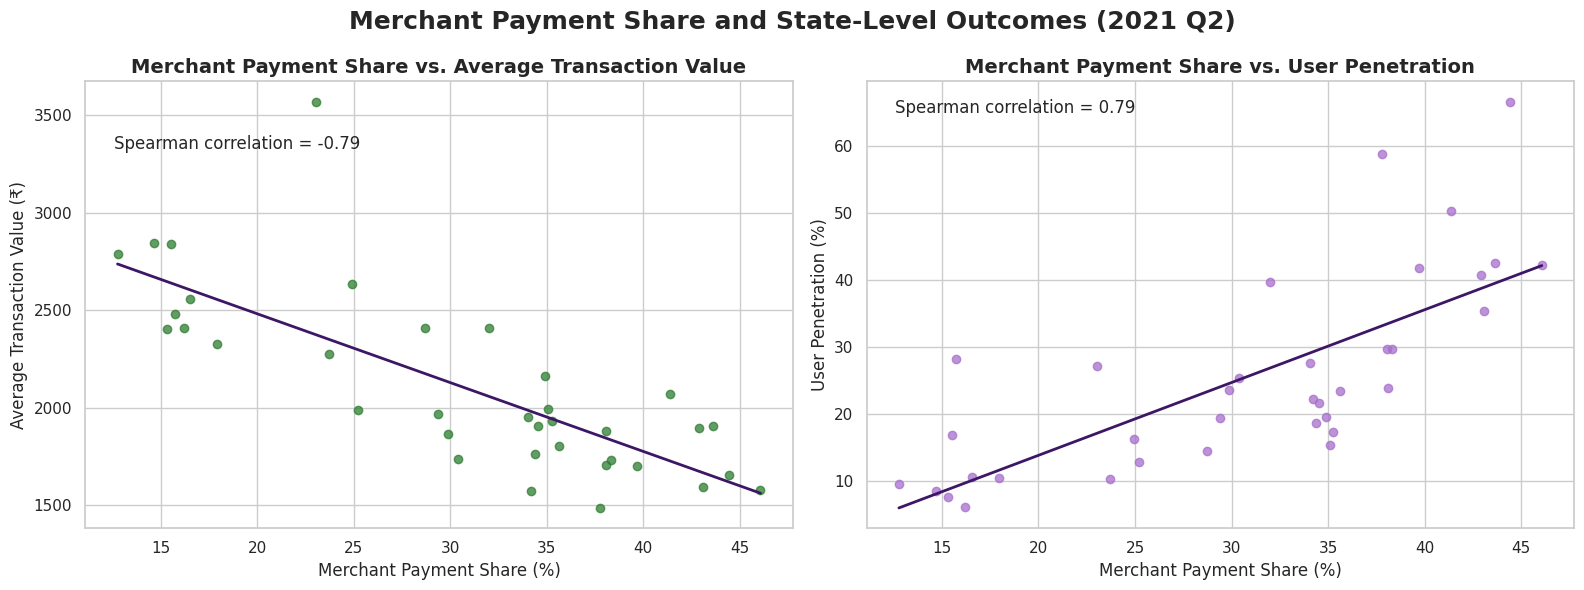

In [93]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
sns.regplot(data=state_analysis,x="Merchant payments Share (%)",y="Avg Transaction Value (INR)",ax=axes[0],ci=None,scatter_kws={"color": MONEY_GREEN,"alpha": 0.75},line_kws={"color": PHONEPE_DARK_PURPLE, "linewidth": 2})
axes[0].set_title("Merchant Payment Share vs. Average Transaction Value", fontweight="bold",fontsize=14)
axes[0].set_xlabel("Merchant Payment Share (%)",fontsize=12)
axes[0].set_ylabel("Average Transaction Value (₹)",fontsize=12)
axes[0].text(0.04,0.88,f"Spearman correlation = {merchant_atv_spearman:.2f}",transform=axes[0].transAxes,verticalalignment="top")
axes[0].set_axisbelow(True)

sns.regplot(data=state_analysis,x="Merchant payments Share (%)",y="Users to Population Ratio (%)",ax=axes[1],ci=None,scatter_kws={"color": PHONEPE_LIGHT_PURPLE,"alpha": 0.75},line_kws={"color": PHONEPE_DARK_PURPLE,"linewidth":2})
axes[1].set_title("Merchant Payment Share vs. User Penetration", fontweight="bold",fontsize=14)
axes[1].set_xlabel("Merchant Payment Share (%)",fontsize=12)
axes[1].set_ylabel("User Penetration (%)",fontsize=12)
axes[1].text(0.04,0.96,f"Spearman correlation = {merchant_penetration_spearman:.2f}",transform=axes[1].transAxes,verticalalignment="top")
axes[1].set_axisbelow(True)

fig.suptitle("Merchant Payment Share and State-Level Outcomes (2021 Q2)",fontweight="bold",fontsize=18)
plt.tight_layout()
plt.show()

**Insights: Merchant Payment Share vs. State-Level Outcomes (2021 Q2)**

- **Lower average transaction value at higher merchant-payment shares:** The chart shows a strong negative rank association between merchant-payment share and average transaction value (**Spearman ρ = −0.79**). ATV generally trends lower as merchant-payment share rises, though there is variation and a notable high-value outlier.
- **Higher user penetration at higher merchant-payment shares:** Merchant-payment share has a strong positive rank association with user penetration (**Spearman ρ = +0.79**). States with higher merchant-payment shares generally also have higher user penetration, although individual states vary.
- **Interpretation:** Together, these patterns suggest that merchant payments are more prominent in states where PhonePe has broader user reach, while average ticket sizes tend to be lower.
- **Cross-sectional caveat:** These are rank-based associations across 36 states in 2021 Q2. They describe differences between states at that time; they do not show changes over time, individual user behavior, or that merchant payments directly cause ticket values to change.

## **District Demographics and Digital Adoption (2021 Q2)**

This section checks whether crowded (high-density) districts have more transactions per person and higher user penetration than spread-out (low-density) districts.

In [94]:
latest_dist_txns = district_txns[(district_txns["Year"] == latest_year) & (district_txns["Quarter"] == latest_quarter)]
district_latest = pd.merge(latest_dist_txns,district_demo[["Code","Population","Density"]],on="Code",how="inner")
district_latest = district_latest[district_latest["Population"] > 0].copy()
district_latest["Transactions per Capita"] = district_latest["Transactions"] / district_latest["Population"]
district_latest["Users Penetration"] = district_latest["Registered Users"] / district_latest["Population"]
district_latest["Avg Transaction Value (INR)"] = district_latest["Amount (INR)"] / district_latest["Transactions"]
district_latest.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Population,Density,Transactions per Capita,Users Penetration,Avg Transaction Value (INR)
0,Andaman & Nicobar Islands,2021,2,Nicobars,AN01,15307,"48,020,606.75","3,137.17",1699,381815,36842,20,0.42,0.05,"3,137.17"
1,Andaman & Nicobar Islands,2021,2,North And Middle Andaman,AN02,39200,"90,233,388.79","2,301.87",8493,596182,105597,28,0.37,0.08,"2,301.87"
2,Andaman & Nicobar Islands,2021,2,South Andaman,AN03,286907,"760,893,020.57","2,652.05",51903,1270226,238142,89,1.20,0.22,"2,652.05"
3,Andhra Pradesh,2021,2,Anantapur,AP01,25123346,"60,987,487,571.28","2,427.52",1492738,104568606,4083315,213,6.15,0.37,"2,427.52"
4,Andhra Pradesh,2021,2,Chittoor,AP02,34344902,"73,654,690,122.43","2,144.56",1870723,110505432,4170468,275,8.24,0.45,"2,144.56"


In [95]:
tier_data = district_latest[district_latest["Population"]>0].copy()
tier_data["Density Group"] = pd.qcut(tier_data["Density"],q=3,labels=["Low Density","Medium Density","High Density"])
tier_summary = tier_data.groupby("Density Group",as_index=False,observed=False)[["Transactions per Capita","Users Penetration"]].median()
tier_summary

,Density Group,Transactions per Capita,Users Penetration
0,Low Density,1.06,0.15
1,Medium Density,1.17,0.19
2,High Density,1.05,0.17


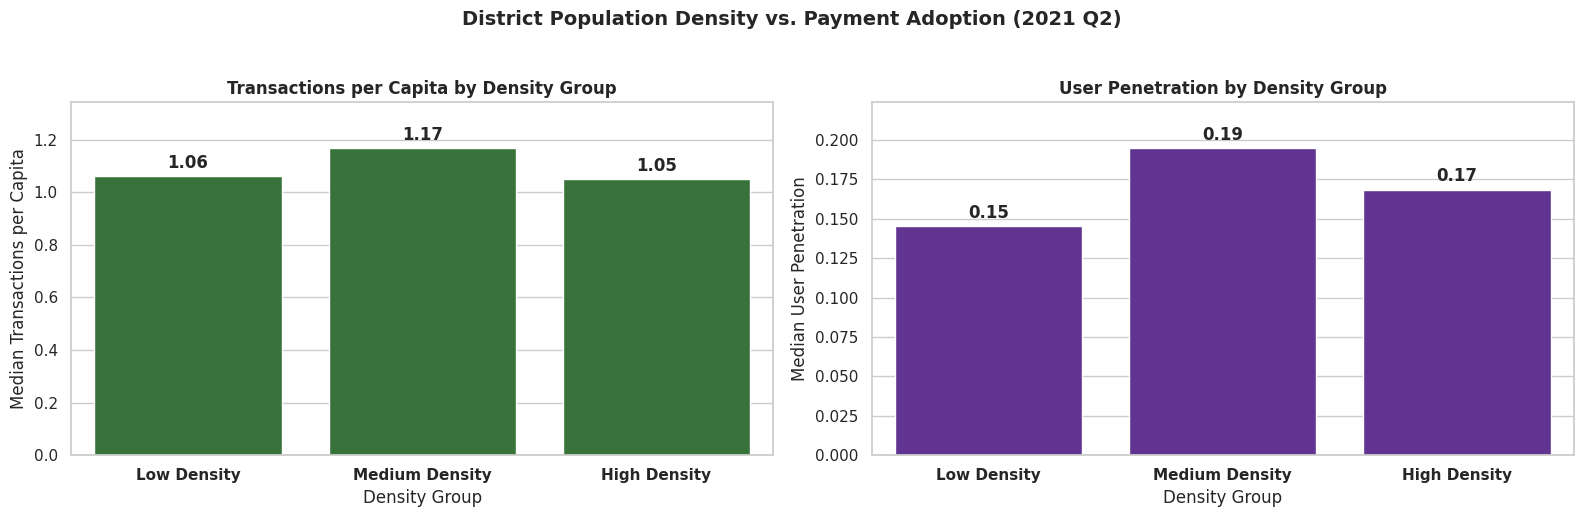

In [96]:
fig,axes = plt.subplots(1,2,figsize=(16,5))
sns.barplot(data=tier_summary,x="Density Group",y="Transactions per Capita",ax=axes[0],color=MONEY_GREEN)
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", padding=3,fontweight="bold")
axes[0].set_ylim(0, tier_summary["Transactions per Capita"].max() * 1.15)
axes[0].set_title("Transactions per Capita by Density Group", fontweight="bold")
axes[0].set_xlabel("Density Group")
axes[0].set_ylabel("Median Transactions per Capita")
axes[0].set_xticks(range(3),["Low Density", "Medium Density", "High Density"],fontweight="bold")


fig.suptitle("District Population Density vs. Payment Adoption (2021 Q2)",fontsize=14,fontweight="bold",y=1.03,)

sns.barplot(data=tier_summary,x="Density Group",y="Users Penetration",ax=axes[1],color=PHONEPE_PURPLE)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f", padding=3,fontweight="bold")
axes[1].set_ylim(0, tier_summary["Users Penetration"].max() * 1.15)
axes[1].set_title("User Penetration by Density Group", fontweight="bold")
axes[1].set_xlabel("Density Group")
axes[1].set_ylabel("Median User Penetration")
axes[1].set_xticks(range(3),["Low Density", "Medium Density", "High Density"],fontweight="bold")


plt.tight_layout()
plt.show()

### Insights: District Density and Payment Adoption (2021 Q2)

- **Consistent individual activity across tiers:** Median transactions per person remain largely steady regardless of population concentration, with **1.06** in low-density, **1.17** in medium-density, and **1.05** in high-density districts. Active users in less crowded regions maintain a comparable quarterly transaction rhythm to those in dense urban centers.
- **Peak penetration in medium-density districts:** User penetration reaches its highest median level in medium-density districts at **0.19** (19%), slightly exceeding high-density (**0.17**) and low-density (**0.15**) districts. Large population bases in dense metropolitan centers dilute per-capita registration ratios despite generating high aggregate user volumes.
- **Methodological note on median selection:** Median values are reported rather than means to prevent extreme metro outliers from distorting typical district-level adoption patterns.
- **Cross-sectional caveat:** These figures capture a single snapshot in 2021 Q2; they illustrate differences between regional tiers at that point in time and do not demonstrate changes over time or individual user behavioral shifts.


### **Device Brand Usage Shift (2018 Q1 vs. 2021 Q2)**

This section compares the distribution of registered users across device brands in 2018 Q1 and 2021 Q2. It highlights how brand usage changed between the two quarters; the comparison does not by itself establish why those changes occurred.

In [97]:
start_mask = (sd["Year"] == 2018) & (sd["Quarter"] == 1)
end_mask = (sd["Year"] == 2021) & (sd["Quarter"] == 2)
device_compare = sd[start_mask | end_mask].copy()
device_compare["Period"] = device_compare["Year"].astype(str) + " Q" + device_compare["Quarter"].astype(str)

In [98]:
brand_summary = device_compare.groupby(["Period","Brand"],as_index=False)["Registered Users"].sum()
period_total = brand_summary.groupby("Period")["Registered Users"].transform("sum")
brand_summary["Share (%)"] = brand_summary["Registered Users"] / period_total * 100
top_5_brands = brand_summary[(brand_summary["Period"] == "2021 Q2") & (brand_summary["Brand"] != "Others")].nlargest(5,"Share (%)")["Brand"].tolist()
brand_summary["Display Brand"] = brand_summary["Brand"].where(brand_summary["Brand"].isin(top_5_brands), "Others")
final_brands = brand_summary.groupby(["Period","Display Brand"],as_index=False)["Share (%)"].sum()
brand_order = final_brands[(final_brands["Period"] == "2021 Q2") & (final_brands["Display Brand"]!= "Others")].sort_values(by="Share (%)", ascending=False)["Display Brand"].tolist()
brand_order.append("Others")

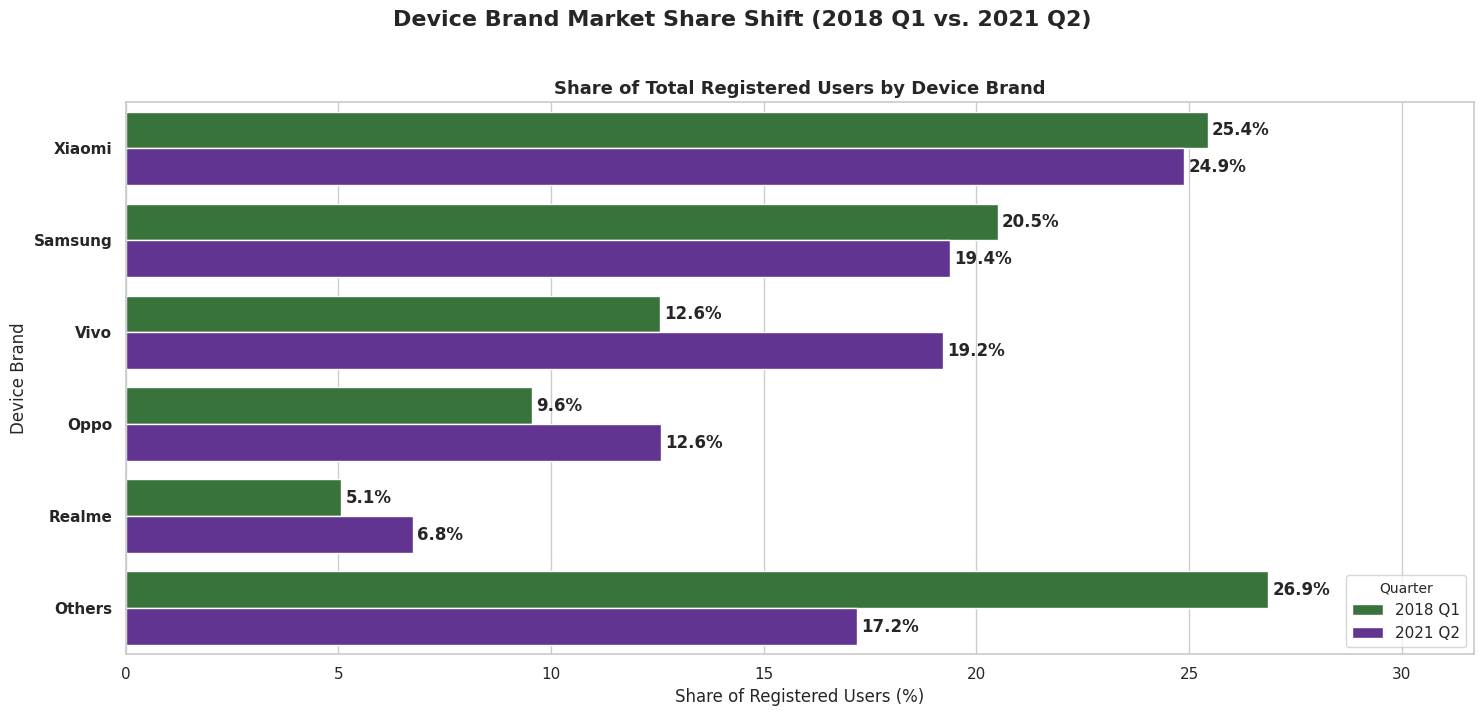

In [99]:
fig,ax = plt.subplots(figsize=(15,7))
fig.suptitle("Device Brand Market Share Shift (2018 Q1 vs. 2021 Q2)",fontweight="bold",fontsize=16,y=1.02)
sns.barplot(data=final_brands,x="Share (%)",y="Display Brand",hue="Period",order=brand_order,palette={"2018 Q1": MONEY_GREEN, "2021 Q2": PHONEPE_PURPLE},ax=ax)
ax.set_title("Share of Total Registered Users by Device Brand",fontsize=13,fontweight="bold")
ax.set_xlabel("Share of Registered Users (%)",fontsize=12)
ax.set_ylabel("Device Brand",fontsize=12)
ax.set_xlim(0, final_brands["Share (%)"].max() * 1.18)
ax.set_yticks(range(len(brand_order)), brand_order, fontweight="bold")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontweight="bold")
ax.bar_label(ax.containers[1], fmt="%.1f%%", padding=3, fontweight="bold")

ax.legend(title="Quarter", title_fontsize="10", loc="lower right")

plt.tight_layout()
plt.show()



**Insights: Mobile Brand Consolidation (2018 Q1 vs. 2021 Q2)**

- **Persistent market leadership by Xiaomi and Samsung:** Xiaomi maintained its position as the top device brand across India, accounting for **25.4%** of registered users in 2018 Q1 and **24.9%** in 2021 Q2. Samsung sustained a steady second-place presence, registering **20.5%** in 2018 Q1 and **19.4%** in 2021 Q2.
- **Substantial gains across BBK Group brands (Vivo, Oppo, Realme):** Value-tier manufacturers captured the largest increases in user share. Vivo rose markedly from **12.6%** to **19.2%**, virtually matching Samsung by 2021 Q2. Oppo expanded from **9.6%** to **12.6%**, while Realme grew from **5.1%** to **6.8%**.
- **Contraction of secondary and legacy OEMs:** The aggregate footprint of all other handset brands combined ("Others") declined sharply from 26.9% down to 17.2%. This means the smaller and legacy brands lost relative share as registrations concentrated among the leading Android manufacturers.
- **Ecosystem concentration:** By 2021 Q2, the top five brands comprised **82.8%** of all registered users (up from **73.1%** in 2018 Q1), confirming that engineering, testing, and UI optimization efforts must be concentrated across these five hardware OEM environments.

## **User Engagement Analysis: App Opens vs. Transactions**

This section explores how often PhonePe app opens lead to a transaction. By comparing total "App Opens" against "Transactions," we can observe whether users are becoming more intentional (transacting whenever they open the app) or opening the app without transacting. Note that "conversion" here means total transactions divided by total app opens, a ratio of counts rather than a session-level conversion rate.

In [100]:
# Filter drops periods prior to 2019 Q3 due to missing/partial telemetry

national_eng = txns.groupby(["Year","Quarter"],as_index=False)[["App Opens","Transactions"]].sum().sort_values(["Year","Quarter"]).reset_index(drop=True)
national_eng = national_eng[national_eng["App Opens"]>1e9].copy()
national_eng["Period"] = national_eng["Year"].astype(str) + " Q" + national_eng["Quarter"].astype(str)
national_eng["Txns per 100 App Opens"] = national_eng["Transactions"] / national_eng["App Opens"] * 100
national_eng["App Opens (billions)"] = national_eng["App Opens"] / 1e9
national_eng["Transactions (billions)"] = national_eng["Transactions"] / 1e9
national_eng

,Year,Quarter,App Opens,Transactions,Period,Txns per 100 App Opens,App Opens (billions),Transactions (billions)
6,2019,3,3448355858,1095009675,2019 Q3,31.75,3.45,1.10
7,2019,4,4301061532,1460443663,2019 Q4,33.96,4.30,1.46
8,2020,1,4768934587,1623038046,2020 Q1,34.03,4.77,1.62
9,2020,2,4357622260,1448608890,2020 Q2,33.24,4.36,1.45
10,2020,3,5739306412,2033051183,2020 Q3,35.42,5.74,2.03
11,2020,4,7461591732,2869276622,2020 Q4,38.45,7.46,2.87
12,2021,1,8635472151,3457585463,2021 Q1,40.04,8.64,3.46
13,2021,2,9630577372,3941370465,2021 Q2,40.93,9.63,3.94


In [101]:
melted_eng = national_eng.melt(id_vars=["Period"],value_vars=["App Opens (billions)","Transactions (billions)"],var_name="Metric",value_name="Billions")
melted_eng.head()

,Period,Metric,Billions
0,2019 Q3,App Opens (billions),3.45
1,2019 Q4,App Opens (billions),4.30
2,2020 Q1,App Opens (billions),4.77
3,2020 Q2,App Opens (billions),4.36
4,2020 Q3,App Opens (billions),5.74


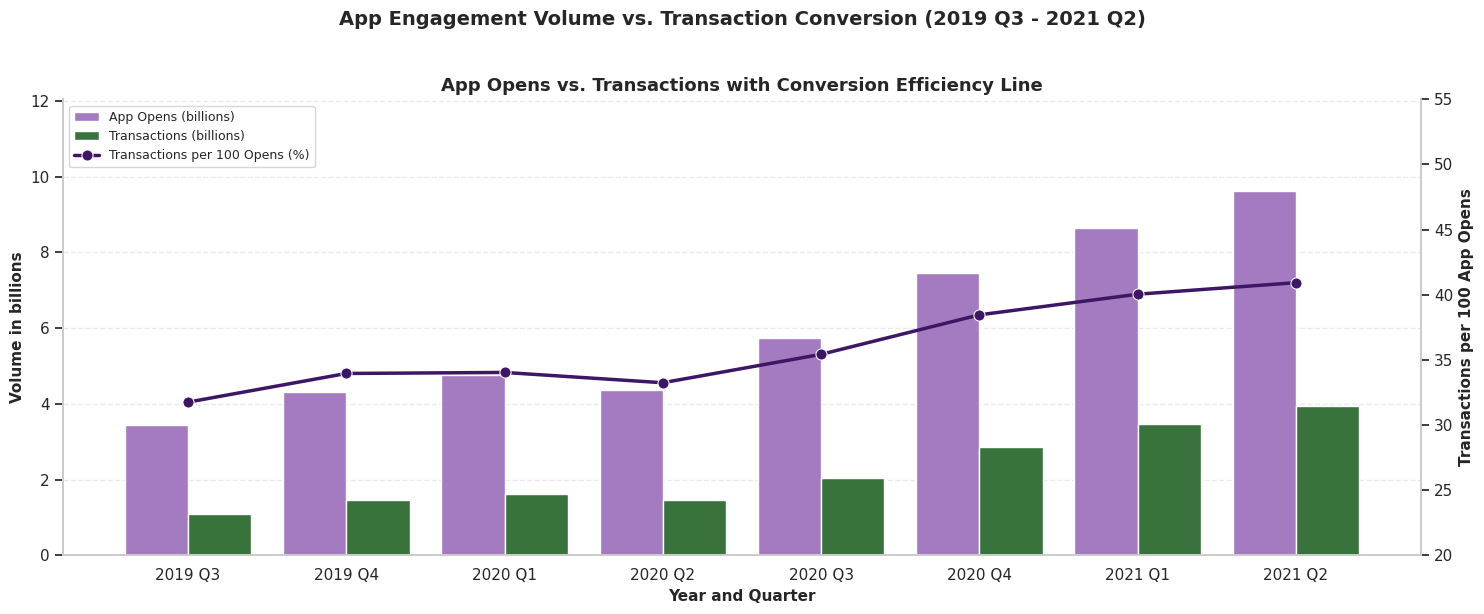

In [102]:
fig,ax1 = plt.subplots(figsize=(15,6))
fig.suptitle("App Engagement Volume vs. Transaction Conversion (2019 Q3 - 2021 Q2)",fontweight="bold",fontsize=14,y=1.02)
sns.barplot(data=melted_eng,x="Period",y="Billions",hue="Metric",palette={"App Opens (billions)": PHONEPE_LIGHT_PURPLE, "Transactions (billions)": MONEY_GREEN},ax=ax1)
ax1.set_title("App Opens vs. Transactions with Conversion Efficiency Line",fontsize=13,fontweight="bold")
ax1.set_xlabel("Year and Quarter",fontsize=11,fontweight="bold")
ax1.set_ylabel("Volume in billions",fontsize=11,fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)
ax1.set_ylim(0, national_eng["App Opens (billions)"].max() * 1.25)

ax2 = ax1.twinx()
sns.lineplot(data=national_eng,x="Period",y="Txns per 100 App Opens",marker='o',color=PHONEPE_DARK_PURPLE,ax=ax2,linewidth=2.5,markersize=8,label="Transactions per 100 Opens (%)")
ax2.set_ylabel("Transactions per 100 App Opens",fontsize=11,fontweight="bold")
ax2.set_ylim(20,55)

lines_1,labels_1 = ax1.get_legend_handles_labels()
lines_2,labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left",fontsize=9)
ax2.get_legend().remove()
ax2.grid(False)
sns.despine(top=True, right=False)

plt.tight_layout()
plt.show()

**Insights: App Engagement & Transaction Activity (2019 Q3 – 2021 Q2)**

- **Data quality & telemetry baseline:** `App opens` were unrecorded (`0`) throughout 2018 and early 2019, likely because app-open tracking had not yet been rolled out. Tracking began in 2019 Q2 with an artificial conversion spike (~88.6%), which likely reflects a partial rollout, before fully stabilizing nationally in **2019 Q3** at **3.45 billion opens** and an operational baseline of **31.8% conversion**. Early unrecorded quarters were excluded to ensure accurate trend analysis.
- **Sustained conversion growth:** After establishing this baseline, transaction conversion expanded across successive periods, reaching **40.9%** by 2021 Q2. Approximately 4 out of every 10 app launches resulted directly in a finalized transaction.
- **High-volume non-transacting app opens:** App opens grew from **3.45 billion** to **9.63 billion** over this timeframe. The remaining **~59%** of app opens did not result in a transaction. The data does not show what users did in those sessions, so this is best read as engagement beyond payments.
- **Pandemic impact and structural recovery:** The initial lockdown disruption in **2020 Q2** caused a temporary contraction in overall app opens (down to **4.36 billion**) and transaction count (**1.45 billion**). However, the conversion rate proved stable at **33.2%**, followed by quarterly growth through late 2020 and 2021 as digital payments became more widely used.


# **Strategic Findings, Insights & Recommendations**

## **1. Project Summary**
Between early 2018 and mid-2021, PhonePe moved from being mainly a recharge app to one where person-to-person and merchant payments became the largest categories. This growth is consistent with cheaper 4G smartphones, wider QR-code acceptance and the shift toward contactless payments during COVID-19, though this dataset cannot isolate those causes. Over the same period, the share of app opens that ended in a transaction also rose.

---

## **2. Core Analytical Findings**

* **How Payment Habits Changed:**
  - Back in 2018, **Recharge & bill payments** was the most common transaction across **91 out of 144** state-quarters. By 2021, it was the leader in only **2 out of 72**.
  - **Peer-to-peer (P2P)** transfers became the biggest category overall from 2019 onward.
  - **Merchant payments** grew the fastest. They did not lead in a single state in 2018, but by mid-2021 they were the top payment type in **15 state-quarters**, showing that merchant payments grew into a mainstream payment type.

* **Smartphones Powering Adoption:**
  - By 2021 Q2, five Android brands accounted for **82.8%** of PhonePe's entire user base: **Xiaomi (24.9%)**, **Samsung (19.4%)**, **Vivo (19.2%)**, **Oppo (12.6%)**, and **Realme (6.8%)**.
  - If we combine the BBK Electronics group (Vivo, Oppo, and Realme), they make up **38.6%** of all devices, even bigger than Xiaomi.
  - Device fragmentation reduced significantly—smaller, miscellaneous brands dropped from **26.9%** down to **17.2%**.

* **State-Level Adoption:**
  - Most transaction volume comes from economically active states like **Karnataka, Maharashtra, Telangana, Andhra Pradesh, and Rajasthan**.
  - Smaller states and union territories (like Lakshadweep, Andaman & Nicobar, Ladakh, and Mizoram) have low total numbers largely because of their smaller populations. However, some of them also have low penetration (Lakshadweep and Mizoram are among the lowest, at roughly 6–8%), and Lakshadweep has the lowest amount per user at about ₹5,593, so population size alone does not explain the gap.

* **App Usage & Conversion:**
  - Quarterly app opens rose from **3.45 billion in 2019 Q3** to **9.63 billion in 2021 Q2**.
  - Conversion efficiency improved steadily from **31.8% to 40.9%**, meaning about 4 out of every 10 app opens directly ended in a payment.
  - The other **~59% of app opens** did not lead to a transaction, and the data does not show what those sessions were for.

---

## **3. Strategic Business Recommendations**


1. **Grow users in high-population, low-penetration states:**
   - Uttar Pradesh (15.4% of population registered), Bihar (14.4%) and West Bengal (19.4%) are all well below the national ratio of 24.7%. Together they would need about 34.6 million more registered users to reach it (UP ~19.1M, Bihar ~10.6M, West Bengal ~4.9M). Focused regional marketing and local-language onboarding should be directed here.
2. **Push merchant onboarding where P2P dominates:**
   - In markets like Andhra Pradesh, where peer-to-peer transfers peak at 54% of volume, merchant payments lag behind national averages. Converting these everyday cash-transfer habits into QR-based retail payments at neighborhood kirana stores is the fastest growth lever.

3. **Drive retail QR acceptance in recharge-heavy states:**
   - In smaller markets like Lakshadweep (48%), Meghalaya (43%), and Mizoram (41%), recharge and bill payments still dominate traffic compared to the 17.4% national average. Launching merchant acquisition drives in these regions will help mature their payment mix.

4. **Partner directly with BBK and Xiaomi for firmware placement:**
   - Xiaomi and the BBK Group (Vivo, Oppo, Realme) account for over 63% of PhonePe’s registered users. Setting up factory pre-installs and lockscreen payment widgets directly on these custom Android skins could help safeguard user acquisition without heavy ad spending.

5. **Optimize app performance for budget chipsets:**
   - Hypothesis to test (not covered by this dataset): device performance on budget phones may affect QR-scan and checkout completion. Testing this would need chipset, RAM and drop-off data.

6. **Monetize non-payment screen time with financial services:**
   - Financial Services and Others together made up only 0.3% of transactions in 2021 Q2, while nearly 59% of app opens do not end in a transaction. Introducing simple, one-tap micro-products (like digital gold or two-wheeler insurance) on the balance summary screen could monetize this attention.